# Sideview glancing-incidence parameter sweep

This notebook compares Fresnel multislice, angular-spectrum multislice, bidirectional WPM, and bidirectional Padé propagation for silicon, molybdenum, and gold. The final experiment contains all 60 combinations of 5, 10, 20, and 30 keV with incidence angles of 1°, 2°, 5°, 10°, and 20°.

The transverse grid is chosen separately for each energy and material family, but it is fixed across the five angles in that family. The 20° carrier is kept below 75% of Nyquist, which is stricter than the requested few-wavelength pixel size and gives approximately 1.1 wavelengths per pixel. The slab depth includes the full four-standard-deviation beam envelope at the exit plane for the largest angle.

The A100 GPU has sufficient memory for the dense Padé operators at the wavelength-scale sampling used here, so the final survey uses a path of approximately 100 nm, rounded up to a whole number of unit cells. The 20° geometry determines the larger transverse window and the corresponding high-energy grid sizes.


In [1]:
import gc
import json
import math
import os
from pathlib import Path
import subprocess
import time
import zipfile

# Set this before importing JAX. The cap is converted to JAX's per-device
# XLA_PYTHON_CLIENT_MEM_FRACTION using the memory reported by nvidia-smi.
# Restart the kernel after changing this value.
JAX_GPU_MEMORY_LIMIT_GIB = 15.0  # Use 10.0 for a tighter cap.
try:
    gpu_memory_mib = int(
        subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=memory.total",
                "--format=csv,noheader,nounits",
            ],
            text=True,
        ).splitlines()[0]
    )
except (FileNotFoundError, IndexError, subprocess.CalledProcessError, ValueError):
    gpu_memory_mib = None

if gpu_memory_mib is not None:
    memory_fraction = min(
        JAX_GPU_MEMORY_LIMIT_GIB * 1024.0 / gpu_memory_mib,
        0.99,
    )
    configured_fraction = os.environ.setdefault(
        "XLA_PYTHON_CLIENT_MEM_FRACTION",
        f"{memory_fraction:.4f}",
    )
    print(
        "JAX GPU memory fraction: "
        f"{configured_fraction} "
        f"(target: {JAX_GPU_MEMORY_LIMIT_GIB:g} GiB)"
    )

import abtem
from ase.build import bulk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import wide_angle_propagation.propagation_methods as pm
from wide_angle_propagation.notebook_utils import resolve_repo_root
from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    simulate_bidirectional_wpm_1d,
    simulate_glancing_angular_spectrum_1d,
    simulate_glancing_fresnel_baseline_1d,
)
from wide_angle_propagation.sideview_geometry import make_tilted_gaussian_beam_1d

abtem.config.set({"device": "cpu", "precision": "float64"})
jax.config.update("jax_enable_x64", True)

REPO_ROOT = resolve_repo_root()


## Experiment controls

The expensive cells are disabled by default. Run the design table first, then set RUN_REPRESENTATIVE_CASE or RUN_FULL_SWEEP to True. Each full-sweep case is cached independently, so an interrupted sweep resumes from the remaining cases.


In [2]:
ENERGIES_KEV = (5.0, 10.0, 20.0, 30.0)
ANGLES_DEG = (1.0, 2.0, 5.0, 10.0, 20.0)
MATERIAL_SPECS = {
    "Si": {"symbol": "Si", "crystalstructure": "diamond", "a_A": 5.431},
    "Mo": {"symbol": "Mo", "crystalstructure": "bcc", "a_A": 3.147},
    "Au": {"symbol": "Au", "crystalstructure": "fcc", "a_A": 4.078},
}
METHODS = ("Fresnel", "Angular spectrum", "WPM", "Pade")
METHOD_COLORS = {
    "Fresnel": "0.20",
    "Angular spectrum": "tab:green",
    "WPM": "tab:blue",
    "Pade": "tab:orange",
}

# The A100-backed final survey uses an approximately 100 nm interaction path.
TARGET_PATH_LENGTH_A = 1000.0
BEAM_WAIST_A = 2.0
BEAM_CLEARANCE_SIGMA = 4.0
BOTTOM_VACUUM_MARGIN_A = 8.0

# The carrier limit controls the grid at 20 degrees; the wavelength cap protects lower-angle edits.
MAX_DU_OVER_WAVELENGTH = 3.0
TILT_NYQUIST_FRACTION_LIMIT = 0.75
GRID_SIZE_BLOCK = 32

# Six samples per unit cell give dz = 0.52--0.91 A for the materials considered here.
SLICES_PER_UNIT_CELL = 6
ABTEM_POTENTIAL_SAMPLING_A = 0.05
WPM_BINS = 32
PADE_ORDER = (4, 4)
BACKSCATTER_SWEEPS = 1

RUN_REPRESENTATIVE_CASE = False
REPRESENTATIVE_CASE = {"material": "Au", "energy_keV": 10.0, "angle_deg": 10.0}
RUN_FULL_SWEEP = False
USE_SAVED_CASES = True
FORCE_RECOMPUTE = False
SAVE_SWEEP_SIDEVIEWS = True
SIDEVIEW_STRIDE = 8

RESULTS_ROOT = (
    REPO_ROOT
    / "notebook_results"
    / "sideview_glancing_incidence_low_energy_methods"
)
CACHE_VERSION = "v7"


## Geometry and sampling design

For an incidence angle θ, the beam is aimed at the surface at the midpoint of the propagation path. Its centre therefore moves from +(L/2)tan(θ) at the entrance to −(L/2)tan(θ) at the exit. The slab depth is set from the 20° exit position plus four beam standard deviations.

For a transverse pixel size du, the sampled carrier occupies a fraction 2 du sin(θ) / λ of the Nyquist frequency. The grid below enforces a maximum fraction of 0.75 for 20°, while also requiring du ≤ 3λ. The maximum-angle constraint is the active one and leads to du ≈ 1.1λ.


In [3]:
def round_up_to_block(value, block):
    return int(math.ceil(value / block) * block)


def design_family_grid(material_label, energy_keV):
    spec = MATERIAL_SPECS[material_label]
    lattice_A = float(spec["a_A"])
    n_path_cells = int(math.ceil(TARGET_PATH_LENGTH_A / lattice_A))
    path_length_A = n_path_cells * lattice_A
    n_steps = n_path_cells * SLICES_PER_UNIT_CELL
    path_step_A = lattice_A / SLICES_PER_UNIT_CELL

    max_angle_rad = math.radians(max(ANGLES_DEG))
    max_centre_reach_A = 0.5 * path_length_A * math.tan(max_angle_rad)
    beam_clearance_A = BEAM_CLEARANCE_SIGMA * BEAM_WAIST_A
    slab_depth_A = max_centre_reach_A + beam_clearance_A
    u_min_A = -slab_depth_A - BOTTOM_VACUUM_MARGIN_A
    u_max_A = max_centre_reach_A + beam_clearance_A
    transverse_span_A = u_max_A - u_min_A

    wavelength_A = float(energy2wavelength(energy_keV * 1e3))
    wavelength_limit_A = MAX_DU_OVER_WAVELENGTH * wavelength_A
    carrier_limit_A = (
        TILT_NYQUIST_FRACTION_LIMIT
        * wavelength_A
        / (2.0 * math.sin(max_angle_rad))
    )
    target_du_A = min(wavelength_limit_A, carrier_limit_A)
    n_u = round_up_to_block(math.ceil(transverse_span_A / target_du_A), GRID_SIZE_BLOCK)
    du_A = transverse_span_A / n_u

    maximum_carrier_fraction = (
        2.0 * du_A * math.sin(max_angle_rad) / wavelength_A
    )
    nyquist_q = wavelength_A / (2.0 * du_A)
    nyquist_angle_deg = math.degrees(math.asin(min(nyquist_q, 1.0)))

    design = {
        "material": material_label,
        "energy_keV": float(energy_keV),
        "lattice_A": lattice_A,
        "n_path_cells": n_path_cells,
        "path_length_A": path_length_A,
        "slab_depth_A": slab_depth_A,
        "u_min_A": u_min_A,
        "u_max_A": u_max_A,
        "transverse_span_A": transverse_span_A,
        "n_steps": n_steps,
        "n_u": n_u,
        "path_step_A": path_step_A,
        "du_A": du_A,
        "wavelength_A": wavelength_A,
        "du_over_wavelength": du_A / wavelength_A,
        "maximum_carrier_nyquist_fraction": maximum_carrier_fraction,
        "nyquist_angle_deg": nyquist_angle_deg,
    }

    assert design["du_over_wavelength"] <= MAX_DU_OVER_WAVELENGTH + 1e-12
    assert maximum_carrier_fraction <= TILT_NYQUIST_FRACTION_LIMIT + 1e-12
    assert nyquist_angle_deg > max(ANGLES_DEG)
    assert np.isclose(path_step_A / lattice_A, 1.0 / SLICES_PER_UNIT_CELL)

    for angle_deg in ANGLES_DEG:
        reach_A = 0.5 * path_length_A * math.tan(math.radians(angle_deg))
        deepest_beam_edge_A = -reach_A - beam_clearance_A
        highest_beam_edge_A = reach_A + beam_clearance_A
        assert deepest_beam_edge_A >= -slab_depth_A - 1e-12
        assert highest_beam_edge_A <= u_max_A + 1e-12
        carrier_fraction = (
            2.0
            * du_A
            * math.sin(math.radians(angle_deg))
            / wavelength_A
        )
        assert carrier_fraction <= TILT_NYQUIST_FRACTION_LIMIT + 1e-12

    return design


family_designs = [
    design_family_grid(material, energy_keV)
    for material in MATERIAL_SPECS
    for energy_keV in ENERGIES_KEV
]

print(
    f"Validated {len(family_designs)} material/energy grids and "
    f"{len(family_designs) * len(ANGLES_DEG)} angle cases."
)
print(
    "material  energy  grid (z,u)  dz [A]  du [A]  du/lambda  "
    "Nyquist angle  depth [A]"
)
for design in family_designs:
    print(
        f"{design['material']:>3s}      {design['energy_keV']:>4.0f}   "
        f"{design['n_steps']:>3d} x {design['n_u']:<4d}   "
        f"{design['path_step_A']:>6.3f}  {design['du_A']:>6.4f}    "
        f"{design['du_over_wavelength']:>6.3f}       "
        f"{design['nyquist_angle_deg']:>6.2f} deg    "
        f"{design['slab_depth_A']:>6.2f}"
    )


Validated 12 material/energy grids and 60 angle cases.
material  energy  grid (z,u)  dz [A]  du [A]  du/lambda  Nyquist angle  depth [A]
 Si         5   1110 x 2080    0.905  0.1874     1.083        27.50 deg    190.85
 Si        10   1110 x 2944    0.905  0.1324     1.085        27.45 deg    190.85
 Si        20   1110 x 4160    0.905  0.0937     1.091        27.28 deg    190.85
 Si        30   1110 x 5120    0.905  0.0761     1.091        27.29 deg    190.85
 Mo         5   1908 x 2048    0.524  0.1896     1.096        27.15 deg    190.12
 Mo        10   1908 x 2912    0.524  0.1333     1.092        27.24 deg    190.12
 Mo        20   1908 x 4128    0.524  0.0941     1.095        27.17 deg    190.12
 Mo        30   1908 x 5088    0.524  0.0763     1.093        27.21 deg    190.12
 Au         5   1476 x 2080    0.680  0.1871     1.081        27.54 deg    190.57
 Au        10   1476 x 2912    0.680  0.1336     1.095        27.17 deg    190.57
 Au        20   1476 x 4160    0.680  0.093

## Periodic sideview potentials

abTEM/Lobato is used to build one projected cubic unit cell for each material. The unit-cell potential is sampled more finely than the propagation grid, then tiled over the slab depth and repeated exactly over six path slices per unit cell. Using an integer number of path cells makes those six slice profiles reusable by the dense Padé propagator.


In [4]:
_UNIT_POTENTIAL_CACHE = {}


def build_unit_projected_potential(material_label):
    if material_label in _UNIT_POTENTIAL_CACHE:
        return _UNIT_POTENTIAL_CACHE[material_label]

    spec = MATERIAL_SPECS[material_label]
    atoms = bulk(
        spec["symbol"],
        spec["crystalstructure"],
        a=spec["a_A"],
        cubic=True,
    )
    atoms.pbc = [True, True, True]
    projection_thickness_A = float(atoms.cell.lengths()[1])
    potential = abtem.Potential(
        atoms,
        sampling=ABTEM_POTENTIAL_SAMPLING_A,
        slice_thickness=projection_thickness_A,
        projection="finite",
        parametrization="lobato",
        plane="xz",
        device="cpu",
    )
    projected = (
        np.asarray(potential.build(lazy=False).array)[0]
        / projection_thickness_A
    )
    unit_du_A, unit_ds_A = (float(value) for value in potential.sampling)
    result = {
        "projected": projected,
        "unit_du_A": unit_du_A,
        "unit_ds_A": unit_ds_A,
        "unit_u_period_A": unit_du_A * projected.shape[0],
        "unit_s_period_A": unit_ds_A * projected.shape[1],
    }
    _UNIT_POTENTIAL_CACHE[material_label] = result
    return result


def build_case_family(material_label, energy_keV):
    design = design_family_grid(material_label, energy_keV)
    unit = build_unit_projected_potential(material_label)

    u_A = design["u_min_A"] + (
        np.arange(design["n_u"]) + 0.5
    ) * design["du_A"]
    slice_keys = np.arange(design["n_steps"]) % SLICES_PER_UNIT_CELL
    slice_phase_A = (slice_keys + 0.5) * design["path_step_A"]

    slab_mask = (u_A >= -design["slab_depth_A"]) & (u_A <= 0.0)
    slab_coordinate_A = u_A[slab_mask] + design["slab_depth_A"]
    u_indices = np.floor(
        np.mod(slab_coordinate_A, unit["unit_u_period_A"]) / unit["unit_du_A"]
    ).astype(int)
    s_indices_by_key = np.floor(
        np.mod(
            (np.arange(SLICES_PER_UNIT_CELL) + 0.5) * design["path_step_A"],
            unit["unit_s_period_A"],
        )
        / unit["unit_ds_A"]
    ).astype(int)

    u_indices = np.clip(u_indices, 0, unit["projected"].shape[0] - 1)
    s_indices_by_key = np.clip(
        s_indices_by_key,
        0,
        unit["projected"].shape[1] - 1,
    )
    s_indices = s_indices_by_key[slice_keys]

    potential_np = np.zeros(
        (design["n_steps"], design["n_u"]),
        dtype=np.float64,
    )
    potential_np[:, slab_mask] = unit["projected"][
        np.ix_(u_indices, s_indices)
    ].T

    assert np.unique(slice_keys).size == SLICES_PER_UNIT_CELL
    assert np.all(np.isfinite(potential_np))
    return {
        **design,
        "u_A": jnp.asarray(u_A),
        "slice_axis_A": (
            np.arange(design["n_steps"]) + 0.5
        ) * design["path_step_A"],
        "slice_keys": slice_keys.astype(int),
        "potential_slices": jnp.asarray(potential_np),
    }


def weighted_quantile(values, weights, quantile):
    values = np.asarray(values, dtype=float).ravel()
    weights = np.asarray(weights, dtype=float).ravel()
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0.0)
    values = values[valid]
    weights = weights[valid]
    order = np.argsort(values)
    cumulative = np.cumsum(weights[order])
    cumulative /= cumulative[-1]
    return float(np.interp(quantile, cumulative, values[order]))


def make_angle_case(family, angle_deg):
    tilt_rad = -math.radians(float(angle_deg))
    input_centre_A = -0.5 * family["path_length_A"] * math.tan(tilt_rad)
    input_wave = make_tilted_gaussian_beam_1d(
        family["u_A"],
        family["energy_keV"] * 1e3,
        waist=BEAM_WAIST_A,
        center=input_centre_A,
        tilt=tilt_rad,
    ).astype(jnp.complex128)

    frequencies = np.fft.fftshift(
        np.fft.fftfreq(family["n_u"], d=family["du_A"])
    )
    q = family["wavelength_A"] * frequencies
    input_power_spectrum = np.abs(
        np.fft.fftshift(np.fft.fft(np.asarray(input_wave)))
    ) ** 2
    input_q99 = weighted_quantile(np.abs(q), input_power_spectrum, 0.99)
    q_nyquist = family["wavelength_A"] / (2.0 * family["du_A"])
    carrier_fraction = (
        2.0
        * family["du_A"]
        * abs(math.sin(tilt_rad))
        / family["wavelength_A"]
    )

    assert carrier_fraction <= TILT_NYQUIST_FRACTION_LIMIT + 1e-12
    assert input_q99 <= 0.90 * q_nyquist

    return {
        **family,
        "angle_deg": float(angle_deg),
        "tilt_rad": tilt_rad,
        "input_centre_A": input_centre_A,
        "input_wave": input_wave,
        "input_q99": input_q99,
        "input_q99_nyquist_fraction": input_q99 / q_nyquist,
    }


## Propagation methods and comparison metrics

Fresnel and angular-spectrum multislice use the same phase-grating split step, so their difference isolates the vacuum propagation kernel. WPM and Padé also change how the refractive-index profile enters the propagation step, and the bidirectional implementations estimate a reflected component. The Padé result is used as the selected numerical reference in the summary metrics. It is not treated as an exact specimen solution because finite Padé order, slice thickness, transverse sampling, and backscatter sweeps remain.


In [5]:
def _precompute_pade_context(family):
    start = time.perf_counter()
    potential_slices = family["potential_slices"]
    slice_keys = np.asarray(family["slice_keys"])
    energy_eV = family["energy_keV"] * 1e3
    k0 = 1.0 / energy2wavelength(energy_eV)
    operators = {}

    for key in np.unique(slice_keys):
        first_index = int(np.flatnonzero(slice_keys == key)[0])
        operator_x, n0 = pm.build_sideview_operator_x_1d(
            potential_slices[first_index],
            family["du_A"],
            energy_eV,
            n0_mode="slice_mean",
            transverse_operator="spectral",
        )
        sqrt_operator = pm._pade_sqrt_matrix(operator_x, PADE_ORDER)
        generator = (
            1j
            * 2.0
            * jnp.pi
            * family["path_step_A"]
            * k0
            * n0
            * sqrt_operator
        )
        forward = jax.scipy.linalg.expm(generator)
        backward = jax.scipy.linalg.expm(-generator)
        forward.block_until_ready()
        backward.block_until_ready()
        operators[int(key)] = {"forward": forward, "backward": backward}

    refractive_maps = pm.klein_gordon_refractive_index_1d(
        potential_slices,
        energy_eV,
    )
    interfaces = [
        pm.interface_scattering_matrix_1d(
            refractive_maps[index],
            refractive_maps[index + 1],
        )
        for index in range(potential_slices.shape[0] - 1)
    ]
    return {
        "operators": operators,
        "interfaces": interfaces,
        "precompute_s": time.perf_counter() - start,
    }


def _apply_interface(scattering_matrix, plus_from_left, minus_from_right):
    plus_right = (
        scattering_matrix[0, 0] * plus_from_left
        + scattering_matrix[0, 1] * minus_from_right
    )
    minus_left = (
        scattering_matrix[1, 0] * plus_from_left
        + scattering_matrix[1, 1] * minus_from_right
    )
    return plus_right, minus_left


def simulate_cached_pade_case(case, context, keep_wavefronts=False):
    slice_keys = np.asarray(case["slice_keys"])
    n_slices = case["potential_slices"].shape[0]
    zero = jnp.zeros_like(case["input_wave"])
    operators = context["operators"]
    interfaces = context["interfaces"]

    def forward_pass(backward_boundary):
        wave_plus = case["input_wave"]
        plus_at_interfaces = [zero for _ in range(n_slices + 1)]
        wavefronts = []
        for index in range(n_slices):
            wave_plus = operators[int(slice_keys[index])]["forward"] @ wave_plus
            if keep_wavefronts:
                wavefronts.append(wave_plus)
            plus_at_interfaces[index + 1] = wave_plus
            if index + 1 < n_slices:
                wave_plus, _ = _apply_interface(
                    interfaces[index],
                    wave_plus,
                    backward_boundary[index + 1],
                )
        return wave_plus, plus_at_interfaces, wavefronts

    def backward_pass(plus_at_interfaces):
        new_backward = [zero for _ in range(n_slices + 1)]
        wave_minus = zero
        for index in range(n_slices - 2, -1, -1):
            new_backward[index + 1] = wave_minus
            _, minus_left = _apply_interface(
                interfaces[index],
                plus_at_interfaces[index + 1],
                wave_minus,
            )
            wave_minus = operators[int(slice_keys[index])]["backward"] @ minus_left
            new_backward[index] = wave_minus
        return new_backward

    backward_boundary = [zero for _ in range(n_slices + 1)]
    residuals = []
    for _ in range(max(int(BACKSCATTER_SWEEPS), 1)):
        _, plus_at_interfaces, _ = forward_pass(backward_boundary)
        new_backward = backward_pass(plus_at_interfaces)
        residuals.append(
            float(
                pm._residual_between_boundary_lists(
                    new_backward,
                    backward_boundary,
                    case["input_wave"],
                )
            )
        )
        backward_boundary = new_backward

    transmitted, plus_at_interfaces, wavefronts = forward_pass(backward_boundary)
    reflected = backward_pass(plus_at_interfaces)[0]
    diagnostics = {
        "residual_per_sweep": residuals,
        "cached_unique_slices": len(operators),
    }
    if keep_wavefronts:
        diagnostics["wavefronts"] = jnp.stack(wavefronts)
    return transmitted, reflected, diagnostics


def run_methods(case, pade_context, keep_wavefronts=False):
    energy_eV = case["energy_keV"] * 1e3
    results = {}
    runtimes = {}

    start = time.perf_counter()
    fresnel_output = simulate_glancing_fresnel_baseline_1d(
        case["input_wave"],
        case["potential_slices"],
        case["du_A"],
        case["path_step_A"],
        energy_eV,
        return_diagnostics=keep_wavefronts,
    )
    if keep_wavefronts:
        fresnel_wave, _, diagnostics = fresnel_output
        fresnel_wavefronts = diagnostics["wavefronts"]
    else:
        fresnel_wave, _ = fresnel_output
        fresnel_wavefronts = None
    fresnel_wave.block_until_ready()
    runtimes["Fresnel"] = time.perf_counter() - start
    results["Fresnel"] = {
        "wave": fresnel_wave,
        "reflected": jnp.zeros_like(fresnel_wave),
        "wavefronts": fresnel_wavefronts,
        "residual_last": 0.0,
    }

    start = time.perf_counter()
    angular_output = simulate_glancing_angular_spectrum_1d(
        case["input_wave"],
        case["potential_slices"],
        case["du_A"],
        case["path_step_A"],
        energy_eV,
        return_diagnostics=keep_wavefronts,
    )
    if keep_wavefronts:
        angular_wave, _, diagnostics = angular_output
        angular_wavefronts = diagnostics["wavefronts"]
    else:
        angular_wave, _ = angular_output
        angular_wavefronts = None
    angular_wave.block_until_ready()
    runtimes["Angular spectrum"] = time.perf_counter() - start
    results["Angular spectrum"] = {
        "wave": angular_wave,
        "reflected": jnp.zeros_like(angular_wave),
        "wavefronts": angular_wavefronts,
        "residual_last": 0.0,
    }

    start = time.perf_counter()
    wpm_wave, wpm_reflected, _, wpm_diagnostics = simulate_bidirectional_wpm_1d(
        case["potential_slices"],
        case["input_wave"],
        case["du_A"],
        case["path_step_A"],
        energy_eV,
        n_bins=WPM_BINS,
        n_sweeps=BACKSCATTER_SWEEPS,
        return_diagnostics=True,
    )
    wpm_wave.block_until_ready()
    runtimes["WPM"] = time.perf_counter() - start
    wpm_residuals = np.asarray(wpm_diagnostics["residual_per_sweep"])
    results["WPM"] = {
        "wave": wpm_wave,
        "reflected": wpm_reflected,
        "wavefronts": (
            wpm_diagnostics["wavefronts_plus"] if keep_wavefronts else None
        ),
        "residual_last": (
            float(wpm_residuals[-1]) if wpm_residuals.size else 0.0
        ),
    }

    start = time.perf_counter()
    pade_wave, pade_reflected, pade_diagnostics = simulate_cached_pade_case(
        case,
        pade_context,
        keep_wavefronts=keep_wavefronts,
    )
    pade_wave.block_until_ready()
    runtimes["Pade"] = time.perf_counter() - start
    results["Pade"] = {
        "wave": pade_wave,
        "reflected": pade_reflected,
        "wavefronts": pade_diagnostics.get("wavefronts"),
        "residual_last": (
            pade_diagnostics["residual_per_sweep"][-1]
            if pade_diagnostics["residual_per_sweep"]
            else 0.0
        ),
    }
    return results, runtimes


def align_complex_field(candidate, reference):
    scale = jnp.vdot(candidate, reference) / (
        jnp.vdot(candidate, candidate) + 1e-30
    )
    return scale * candidate


def relative_complex_rmse(candidate, reference, mask=None):
    aligned = align_complex_field(candidate, reference)
    if mask is not None:
        aligned = aligned[mask]
        reference = reference[mask]
    return float(
        jnp.linalg.norm(aligned - reference)
        / (jnp.linalg.norm(reference) + 1e-30)
    )


def normalized_profile_rmse(candidate, reference, mask=None):
    candidate = jnp.asarray(candidate)
    reference = jnp.asarray(reference)
    if mask is not None:
        candidate = candidate[mask]
        reference = reference[mask]
    scale = jnp.vdot(candidate, reference) / (
        jnp.vdot(candidate, candidate) + 1e-30
    )
    return float(
        jnp.sqrt(jnp.mean((scale * candidate - reference) ** 2))
        / (jnp.sqrt(jnp.mean(reference**2)) + 1e-30)
    )


def summarize_case(case, results, runtimes, pade_precompute_s):
    farfields = {
        method: jnp.abs(
            jnp.fft.fftshift(jnp.fft.fft(result["wave"]))
        ) ** 2
        for method, result in results.items()
    }
    frequencies = np.fft.fftshift(
        np.fft.fftfreq(case["n_u"], d=case["du_A"])
    )
    detector_angle_deg = np.degrees(
        np.arcsin(
            np.clip(
                frequencies * case["wavelength_A"],
                -1.0,
                1.0,
            )
        )
    )
    positive_mask = detector_angle_deg > 0.0
    reference_wave = results["Pade"]["wave"]
    reference_intensity = jnp.abs(reference_wave) ** 2
    exit_mask = reference_intensity > 1e-3 * jnp.max(reference_intensity)
    input_power = float(jnp.sum(jnp.abs(case["input_wave"]) ** 2))
    detector_normalization = case["n_u"] * input_power + 1e-30

    metrics = {}
    for method, result in results.items():
        method_intensity = jnp.abs(result["wave"]) ** 2
        q99 = weighted_quantile(
            np.abs(
                case["wavelength_A"]
                * np.fft.fftshift(
                    np.fft.fftfreq(case["n_u"], d=case["du_A"])
                )
            ),
            np.asarray(farfields[method]),
            0.99,
        )
        metrics[method] = {
            "exit_field_rmse_vs_pade": relative_complex_rmse(
                result["wave"],
                reference_wave,
                exit_mask,
            ),
            "exit_intensity_rmse_vs_pade": normalized_profile_rmse(
                method_intensity,
                reference_intensity,
                exit_mask,
            ),
            "positive_farfield_rmse_vs_pade": normalized_profile_rmse(
                farfields[method],
                farfields["Pade"],
                positive_mask,
            ),
            "positive_detected_power_fraction": float(
                jnp.sum(farfields[method][positive_mask])
            )
            / detector_normalization,
            "reflected_power_fraction": float(
                jnp.sum(jnp.abs(result["reflected"]) ** 2)
            )
            / (input_power + 1e-30),
            "transmitted_power_fraction": float(jnp.sum(method_intensity))
            / (input_power + 1e-30),
            "exit_q99": q99,
            "runtime_s": float(runtimes[method]),
            "residual_last": float(result["residual_last"]),
        }

    row = {
        "material": case["material"],
        "energy_keV": case["energy_keV"],
        "angle_deg": case["angle_deg"],
        "grid_shape": [case["n_steps"], case["n_u"]],
        "path_length_A": case["path_length_A"],
        "slab_depth_A": case["slab_depth_A"],
        "sampling_A": [case["path_step_A"], case["du_A"]],
        "wavelength_A": case["wavelength_A"],
        "du_over_wavelength": case["du_over_wavelength"],
        "carrier_nyquist_fraction": (
            2.0
            * case["du_A"]
            * math.sin(math.radians(case["angle_deg"]))
            / case["wavelength_A"]
        ),
        "input_q99_nyquist_fraction": case["input_q99_nyquist_fraction"],
        "pade_precompute_s_family": float(pade_precompute_s),
        "metrics": metrics,
    }
    assert all(
        np.isfinite(value)
        for method_metrics in metrics.values()
        for value in method_metrics.values()
    )
    return row, farfields, detector_angle_deg


## Case caching and execution

Each case stores exit waves, reflected waves, far-field intensities, coordinates, and JSON metadata. When SAVE_SWEEP_SIDEVIEWS is enabled, the cache also stores float32 forward-wave intensity arrays for all four methods. Complex sideview wavefronts are retained in memory only for the optional representative case.


In [6]:
def method_key(method):
    return method.lower().replace(" ", "_")


CACHE_TAG = (
    f"path{TARGET_PATH_LENGTH_A:.0f}A_spc{SLICES_PER_UNIT_CELL}_"
    f"tilt{TILT_NYQUIST_FRACTION_LIMIT:.2f}_"
    f"wpm{WPM_BINS}_pade{PADE_ORDER[0]}{PADE_ORDER[1]}_"
    f"sweeps{BACKSCATTER_SWEEPS}_{CACHE_VERSION}"
).replace(".", "p")
CASE_CACHE_DIR = RESULTS_ROOT / CACHE_TAG
SUMMARY_PATH = CASE_CACHE_DIR / "sweep_summary.json"


def case_cache_has_required_arrays(path):
    if not path.exists():
        return False
    if not SAVE_SWEEP_SIDEVIEWS:
        return True
    required = {
        f"{method_key(method)}_sideview_intensity"
        for method in METHODS
    }
    try:
        with np.load(path, allow_pickle=False) as data:
            return required.issubset(data.files)
    except (OSError, ValueError, EOFError, zipfile.BadZipFile):
        return False


def case_cache_path(material, energy_keV, angle_deg):
    angle_label = f"{angle_deg:04.1f}".replace(".", "p")
    return CASE_CACHE_DIR / (
        f"{material}_{energy_keV:04.0f}keV_{angle_label}deg.npz"
    )


def load_cached_row(path):
    with np.load(path, allow_pickle=False) as data:
        row = json.loads(data["metadata_json"].item())
    row["cache_file"] = str(path.relative_to(REPO_ROOT))
    row["loaded_from_cache"] = True
    return row


def save_case(path, case, row, results, farfields, detector_angle_deg):
    path.parent.mkdir(parents=True, exist_ok=True)
    arrays = {
        "metadata_json": np.array(json.dumps(row)),
        "u_A": np.asarray(case["u_A"]),
        "slice_axis_A": np.asarray(case["slice_axis_A"]),
        "detector_angle_deg": np.asarray(detector_angle_deg),
        "sideview_u_A": np.asarray(case["u_A"])[::SIDEVIEW_STRIDE],
        "sideview_slice_axis_A": np.asarray(case["slice_axis_A"])[::SIDEVIEW_STRIDE],
    }
    for method in METHODS:
        key = method_key(method)
        arrays[f"{key}_exit"] = np.asarray(results[method]["wave"])
        arrays[f"{key}_reflected"] = np.asarray(results[method]["reflected"])
        arrays[f"{key}_farfield"] = np.asarray(farfields[method])
        if results[method]["wavefronts"] is not None:
            sideview_intensity = np.asarray(
                jnp.abs(results[method]["wavefronts"]) ** 2,
                dtype=np.float32,
            )
            arrays[f"{key}_sideview_intensity"] = sideview_intensity[
                ::SIDEVIEW_STRIDE,
                ::SIDEVIEW_STRIDE,
            ]
    np.savez_compressed(path, **arrays)


def execute_case(
    case,
    pade_context,
    *,
    keep_wavefronts=False,
    save=False,
):
    results, runtimes = run_methods(
        case,
        pade_context,
        keep_wavefronts=keep_wavefronts,
    )
    row, farfields, detector_angle_deg = summarize_case(
        case,
        results,
        runtimes,
        pade_context["precompute_s"],
    )
    cache_path = case_cache_path(
        case["material"],
        case["energy_keV"],
        case["angle_deg"],
    )
    row["cache_file"] = str(cache_path.relative_to(REPO_ROOT))
    row["loaded_from_cache"] = False
    if save:
        save_case(
            cache_path,
            case,
            row,
            results,
            farfields,
            detector_angle_deg,
        )
    return row, results, farfields, detector_angle_deg


def run_full_parameter_sweep():
    CASE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    rows = []

    for material in MATERIAL_SPECS:
        for energy_keV in ENERGIES_KEV:
            paths = [
                case_cache_path(material, energy_keV, angle_deg)
                for angle_deg in ANGLES_DEG
            ]
            can_load = [
                USE_SAVED_CASES
                and not FORCE_RECOMPUTE
                and case_cache_has_required_arrays(path)
                for path in paths
            ]
            if all(can_load):
                rows.extend(load_cached_row(path) for path in paths)
                print(f"loaded {material}, {energy_keV:.0f} keV")
                continue

            family = build_case_family(material, energy_keV)
            pade_context = _precompute_pade_context(family)
            print(
                f"prepared {material}, {energy_keV:.0f} keV "
                f"({family['n_steps']} x {family['n_u']}, "
                f"Padé setup {pade_context['precompute_s']:.1f} s)"
            )

            for angle_deg, path, load_case in zip(ANGLES_DEG, paths, can_load):
                if load_case:
                    row = load_cached_row(path)
                else:
                    case = make_angle_case(family, angle_deg)
                    start = time.perf_counter()
                    row, _, _, _ = execute_case(
                        case,
                        pade_context,
                        keep_wavefronts=SAVE_SWEEP_SIDEVIEWS,
                        save=True,
                    )
                    print(
                        f"  completed {angle_deg:>4.1f} deg in "
                        f"{time.perf_counter() - start:.1f} s"
                    )
                rows.append(row)

            del pade_context
            del family
            gc.collect()

    summary = {
        "methods": list(METHODS),
        "materials": list(MATERIAL_SPECS),
        "energies_keV": list(ENERGIES_KEV),
        "angles_deg": list(ANGLES_DEG),
        "number_of_cases": len(rows),
        "cache_tag": CACHE_TAG,
        "sideview_intensities_saved": SAVE_SWEEP_SIDEVIEWS,
        "results": rows,
    }
    SUMMARY_PATH.write_text(json.dumps(summary, indent=2))
    return rows


## Optional representative case

The representative Au, 10 keV, 10° case retains every forward wavefront for a sideview comparison. It uses the same grid and specimen construction as the full sweep.


In [7]:
representative_case = None
representative_results = None
representative_farfields = None
representative_detector_angle_deg = None
representative_row = None

if RUN_REPRESENTATIVE_CASE:
    representative_family = build_case_family(
        REPRESENTATIVE_CASE["material"],
        REPRESENTATIVE_CASE["energy_keV"],
    )
    representative_case = make_angle_case(
        representative_family,
        REPRESENTATIVE_CASE["angle_deg"],
    )
    representative_pade_context = _precompute_pade_context(
        representative_family
    )
    (
        representative_row,
        representative_results,
        representative_farfields,
        representative_detector_angle_deg,
    ) = execute_case(
        representative_case,
        representative_pade_context,
        keep_wavefronts=True,
        save=False,
    )
    print(json.dumps(representative_row, indent=2))


In [8]:
if representative_results is not None:
    sideview_norm = max(
        float(
            jnp.max(
                jnp.abs(representative_results[method]["wavefronts"]) ** 2
            )
        )
        for method in METHODS
    ) + 1e-30
    pade_exit_intensity = (
        jnp.abs(representative_results["Pade"]["wave"]) ** 2
    )
    positive_mask = representative_detector_angle_deg > 0.0

    fig, axes = plt.subplots(
        len(METHODS),
        3,
        figsize=(15.5, 11.5),
        constrained_layout=True,
        gridspec_kw={"width_ratios": [4.8, 1.3, 2.3]},
    )
    extent = [
        0.0,
        representative_case["path_length_A"],
        representative_case["u_min_A"],
        representative_case["u_max_A"],
    ]

    for row_index, method in enumerate(METHODS):
        result = representative_results[method]
        ax_side, ax_exit, ax_far = axes[row_index]
        sideview = np.sqrt(
            np.asarray(jnp.abs(result["wavefronts"]) ** 2) / sideview_norm
        )
        ax_side.imshow(
            sideview.T,
            extent=extent,
            origin="lower",
            aspect="auto",
            cmap="magma",
            vmin=0.0,
            vmax=1.0,
        )
        ax_side.axhline(0.0, color="cyan", lw=0.8)
        ax_side.axhline(
            -representative_case["slab_depth_A"],
            color="cyan",
            lw=0.8,
        )
        ax_side.set_title(f"{method} sideview amplitude")
        ax_side.set_xlabel("path coordinate [A]")
        ax_side.set_ylabel("u [A]")

        method_exit = jnp.abs(result["wave"]) ** 2
        if method != "Pade":
            ax_exit.plot(
                np.asarray(pade_exit_intensity),
                np.asarray(representative_case["u_A"]),
                color="0.70",
                lw=1.0,
                label="Pade",
            )
        ax_exit.plot(
            np.asarray(method_exit),
            np.asarray(representative_case["u_A"]),
            color=METHOD_COLORS[method],
            lw=1.3,
            label=method,
        )
        ax_exit.set_xlabel("exit intensity [arb. units]")
        ax_exit.set_ylim(
            representative_case["u_min_A"],
            representative_case["u_max_A"],
        )
        ax_exit.grid(alpha=0.2)
        ax_exit.legend(frameon=False, fontsize=8)

        if method != "Pade":
            ax_far.plot(
                representative_detector_angle_deg[positive_mask],
                np.asarray(
                    representative_farfields["Pade"]
                )[positive_mask],
                color="0.70",
                lw=1.0,
                label="Pade",
            )
        ax_far.plot(
            representative_detector_angle_deg[positive_mask],
            np.asarray(
                representative_farfields[method]
            )[positive_mask],
            color=METHOD_COLORS[method],
            lw=1.3,
            label=method,
        )
        ax_far.axvline(
            representative_case["angle_deg"],
            color="tab:red",
            ls="--",
            lw=0.9,
            label="specular",
        )
        ax_far.set_xlabel("positive detector angle [deg]")
        ax_far.set_ylabel("detector intensity [arb. units]")
        ax_far.set_title(
            "far-field RMSE vs Pade = "
            f"{representative_row['metrics'][method]['positive_farfield_rmse_vs_pade']:.2e}"
        )
        ax_far.grid(alpha=0.2)
        ax_far.legend(frameon=False, fontsize=8)

    fig.suptitle(
        f"{representative_case['material']}, "
        f"{representative_case['energy_keV']:.0f} keV, "
        f"{representative_case['angle_deg']:.0f} deg",
        y=1.01,
    )
    plt.show()


## Final 60-case experiment

Set RUN_FULL_SWEEP = True in the controls cell and run from this point. The loop order reuses the six Padé matrices across all five angles for each material/energy family. A cached case is reused only when it contains the requested sideview intensities.


In [9]:
sweep_results = []

if RUN_FULL_SWEEP:
    sweep_results = run_full_parameter_sweep()
    print(f"saved {len(sweep_results)} cases to {SUMMARY_PATH}")
elif SUMMARY_PATH.exists():
    sweep_results = json.loads(SUMMARY_PATH.read_text())["results"]
    print(f"loaded {len(sweep_results)} completed cases from {SUMMARY_PATH}")
else:
    print(
        "Full sweep is configured but not started. "
        "Set RUN_FULL_SWEEP = True after reviewing the design table."
    )

if sweep_results:
    assert len(sweep_results) == (
        len(MATERIAL_SPECS) * len(ENERGIES_KEV) * len(ANGLES_DEG)
    )


loaded 60 completed cases from /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/sweep_summary.json


saved sweep figure to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/farfield_rmse_vs_pade.png


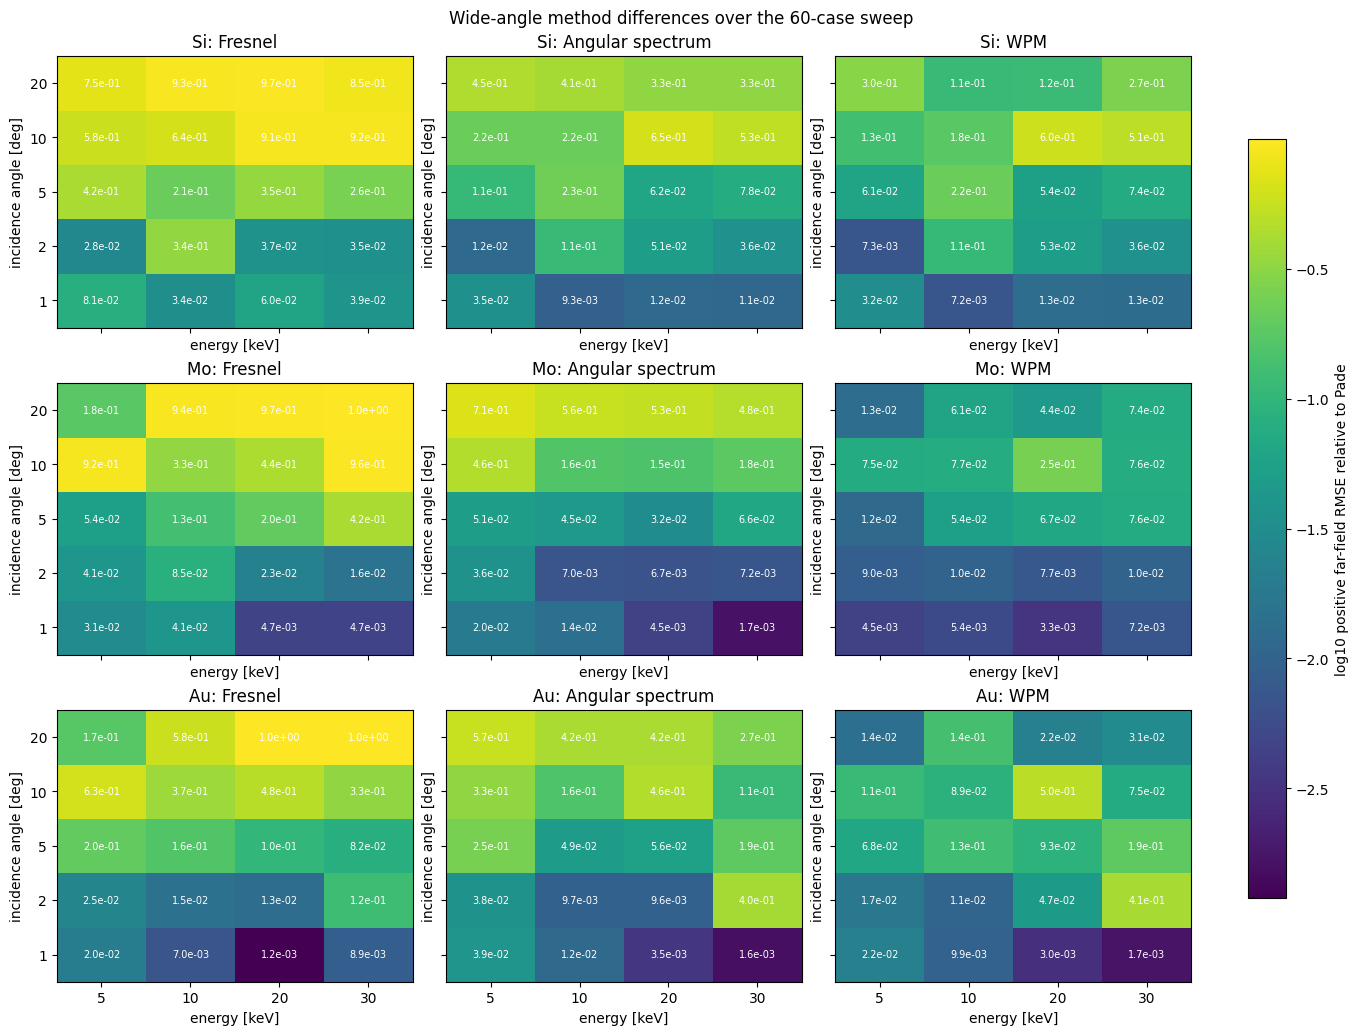

In [10]:
def sweep_metric_grid(rows, material, method, metric):
    values = np.full((len(ANGLES_DEG), len(ENERGIES_KEV)), np.nan)
    for row in rows:
        if row["material"] != material:
            continue
        angle_index = ANGLES_DEG.index(float(row["angle_deg"]))
        energy_index = ENERGIES_KEV.index(float(row["energy_keV"]))
        values[angle_index, energy_index] = row["metrics"][method][metric]
    return values


if sweep_results:
    compared_methods = ("Fresnel", "Angular spectrum", "WPM")
    metric_name = "positive_detected_power_fraction"
    all_values = np.array(
        [
            row["metrics"][method][metric_name]
            for row in sweep_results
            for method in compared_methods
        ]
    )
    log_floor = 1e-12
    color_min = np.log10(max(float(np.min(all_values[all_values > 0])), log_floor))
    color_max = np.log10(max(float(np.max(all_values)), 10.0 * log_floor))

    fig, axes = plt.subplots(
        len(MATERIAL_SPECS),
        len(compared_methods),
        figsize=(13.5, 10.0),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    last_image = None
    for row_index, material in enumerate(MATERIAL_SPECS):
        for column_index, method in enumerate(compared_methods):
            ax = axes[row_index, column_index]
            values = sweep_metric_grid(
                sweep_results,
                material,
                method,
                metric_name,
            )
            last_image = ax.imshow(
                np.log10(np.maximum(values, log_floor)),
                origin="lower",
                aspect="auto",
                vmin=color_min,
                vmax=color_max,
                cmap="viridis",
            )
            ax.set_xticks(np.arange(len(ENERGIES_KEV)))
            ax.set_xticklabels([f"{value:.0f}" for value in ENERGIES_KEV])
            ax.set_yticks(np.arange(len(ANGLES_DEG)))
            ax.set_yticklabels([f"{value:.0f}" for value in ANGLES_DEG])
            ax.set_title(f"{material}: {method}")
            ax.set_xlabel("energy [keV]")
            ax.set_ylabel("incidence angle [deg]")
            for i in range(values.shape[0]):
                for j in range(values.shape[1]):
                    ax.text(
                        j,
                        i,
                        f"{values[i, j]:.1e}",
                        ha="center",
                        va="center",
                        color="white",
                        fontsize=7,
                    )

    colorbar = fig.colorbar(last_image, ax=axes, shrink=0.82)
    colorbar.set_label("log10 positive-angle detected power fraction")
    fig.suptitle(
        "Positive-angle detector signal over the 60-case sweep",
        y=1.02,
    )
    sweep_figure_path = CASE_CACHE_DIR / "positive_detected_power_fraction.png"
    fig.savefig(sweep_figure_path, dpi=180, bbox_inches="tight")
    print(f"saved sweep figure to {sweep_figure_path}")
    plt.show()


## Exit-wave cross-section gallery

Each panel overlays the four exit intensities as functions of the transverse coordinate. The profiles are normalized by the largest peak among the four methods in that case, so the relative position, width, and shape remain visible without allowing the absolute intensity scale to obscure weaker profiles. The solid horizontal line marks the specimen surface at u = 0, whereas the dotted line marks the lower slab boundary. Set CROSS_SECTION_LOG_SCALE = True to inspect weak tails.


saved Si cross sections to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/si_exit_cross_sections.png


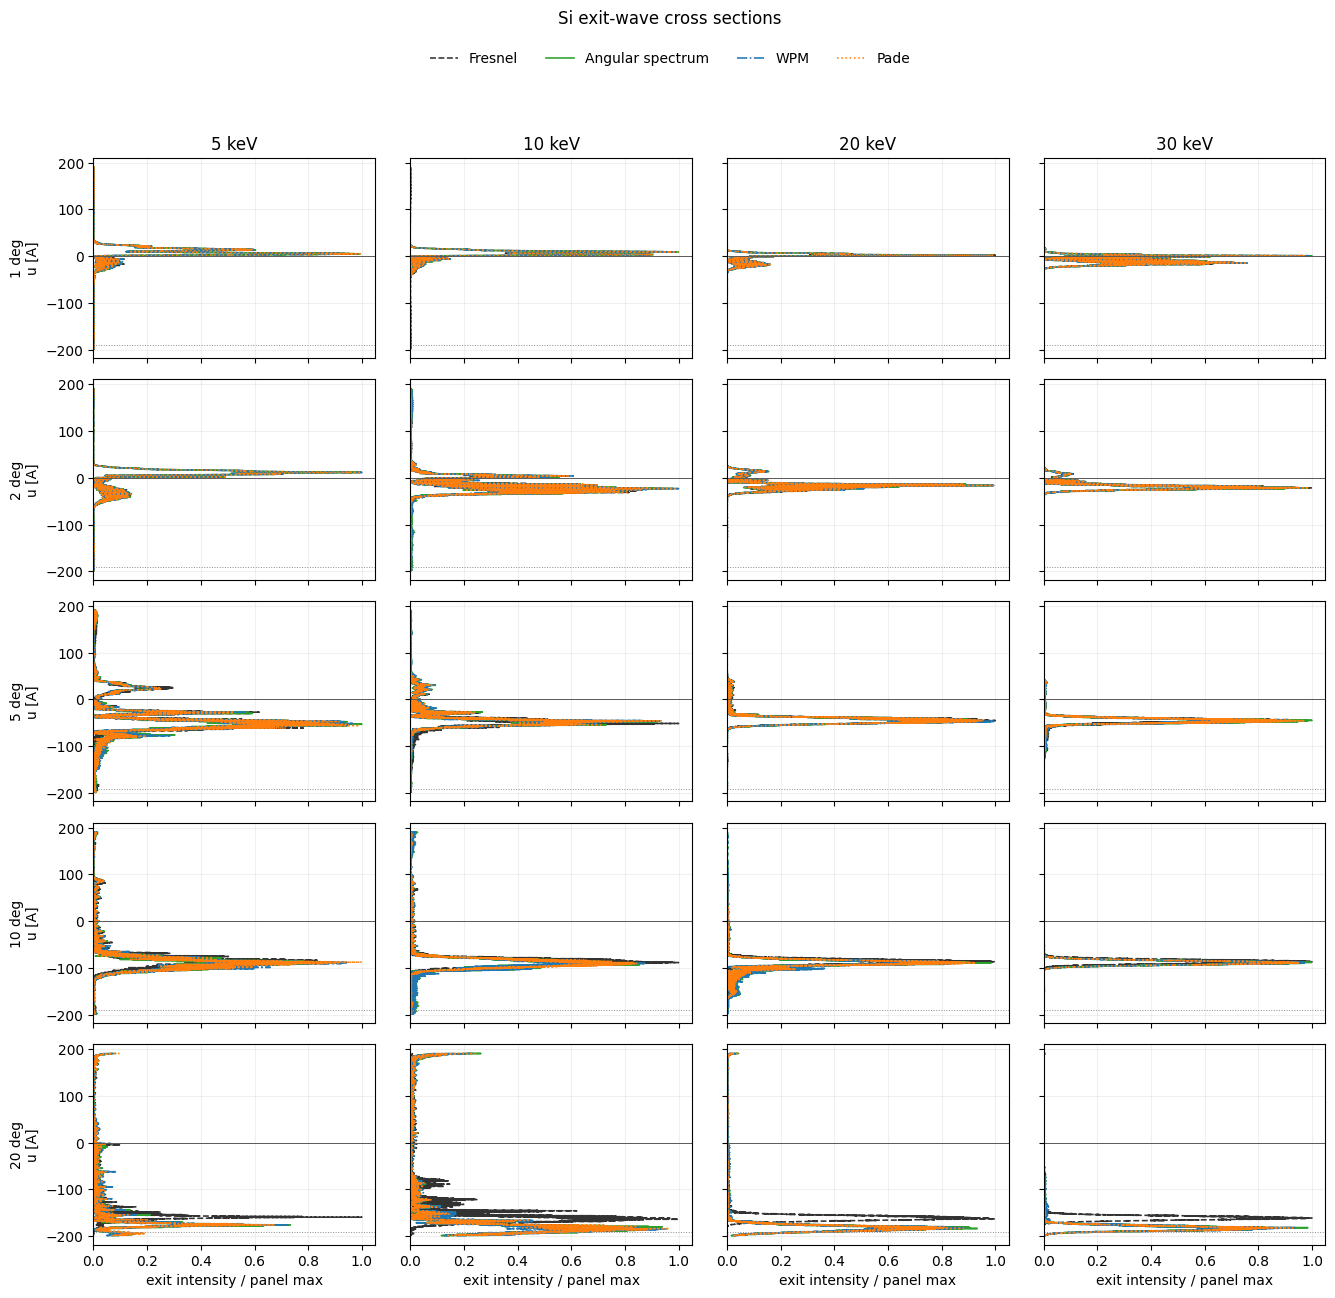

saved Mo cross sections to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/mo_exit_cross_sections.png


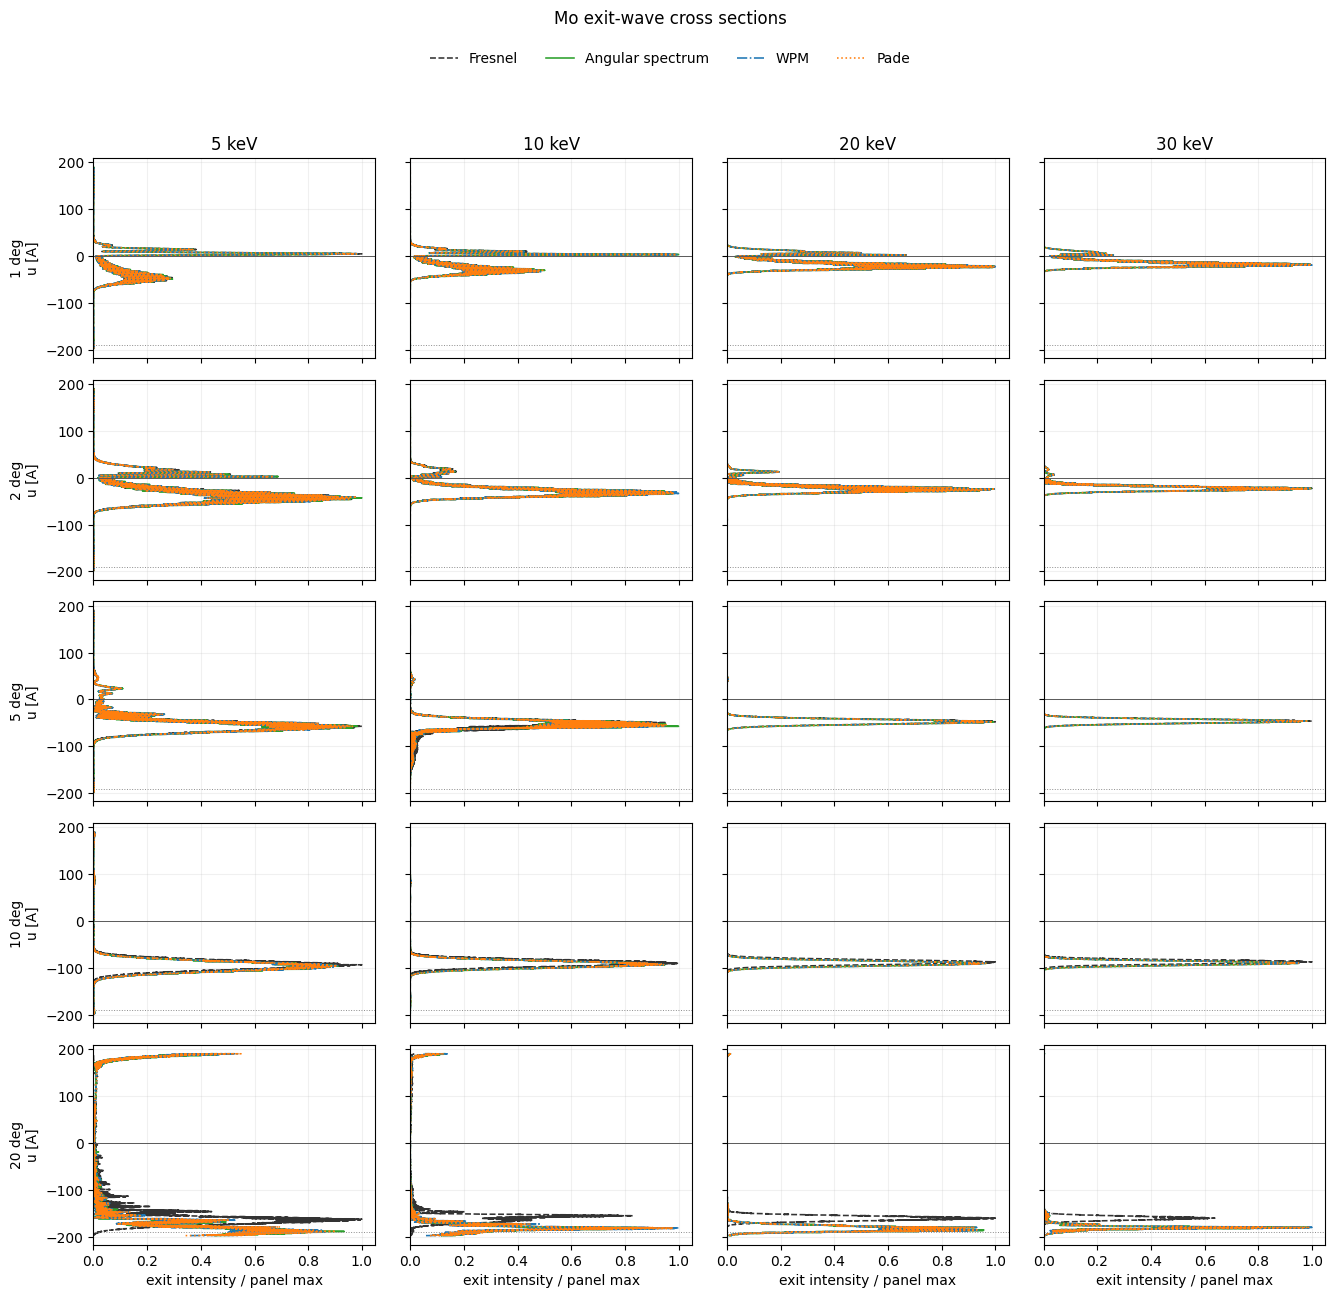

saved Au cross sections to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/au_exit_cross_sections.png


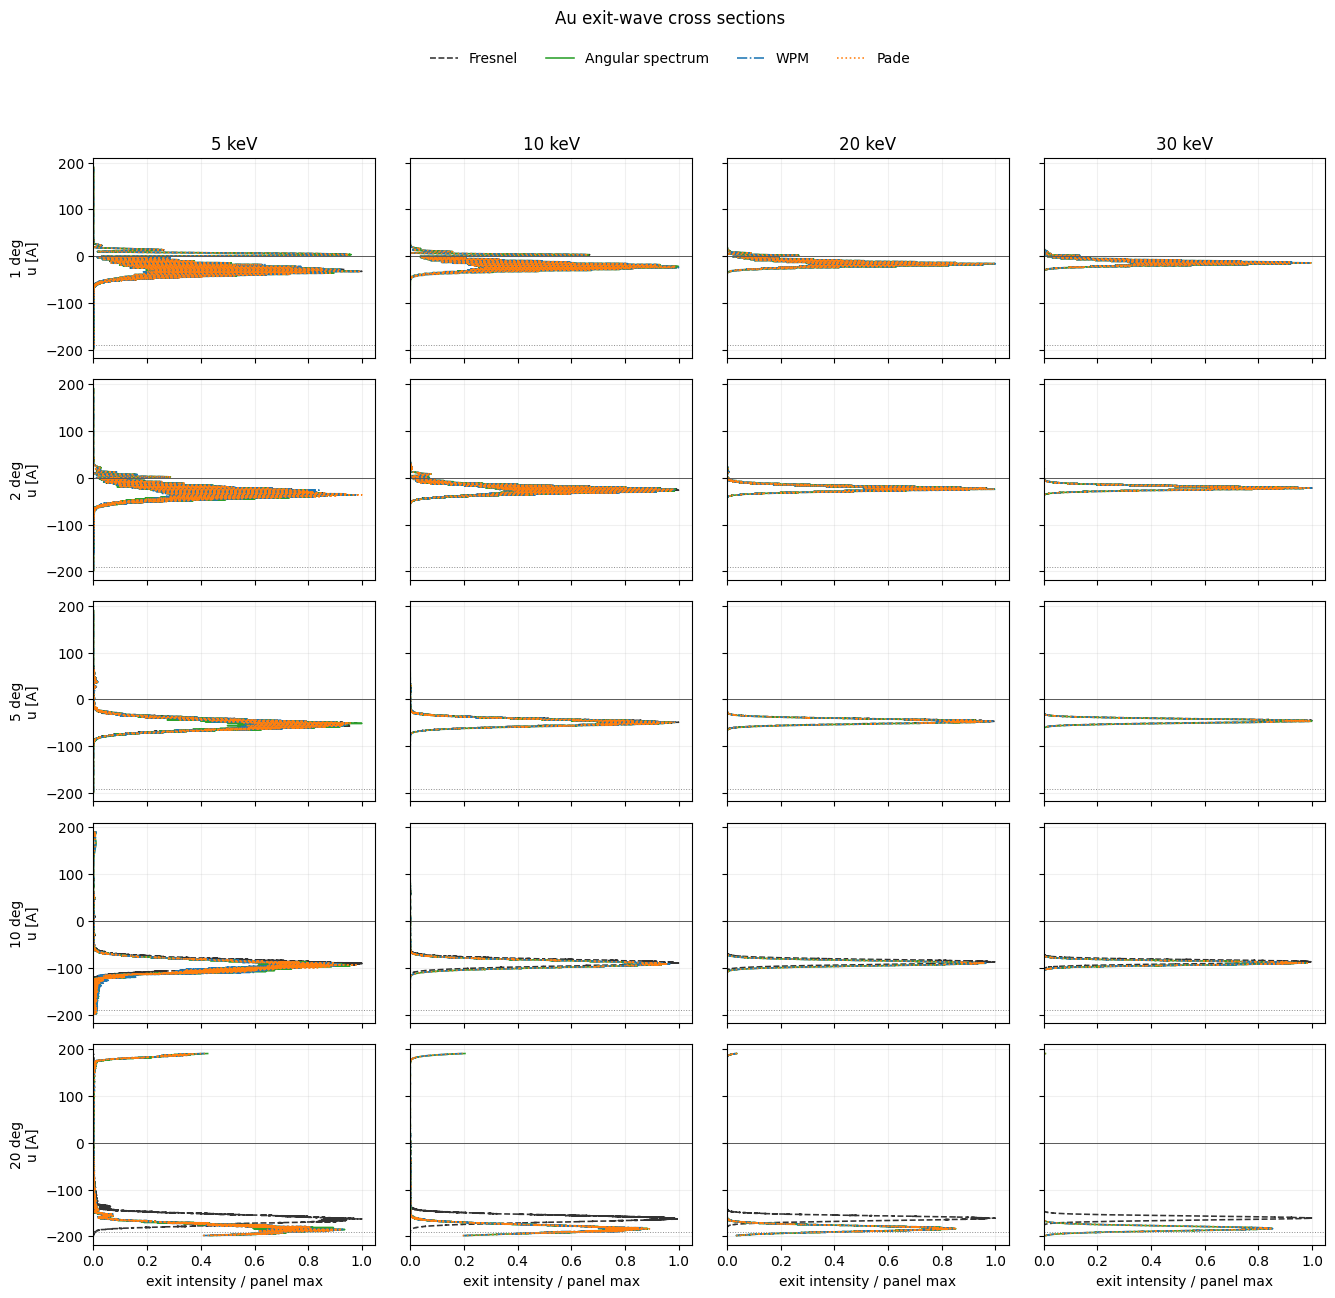

In [11]:
PLOT_SWEEP_CROSS_SECTIONS = True
CROSS_SECTION_LOG_SCALE = False
CROSS_SECTION_LOG_FLOOR = 1e-6
METHOD_LINESTYLES = {
    "Fresnel": "--",
    "Angular spectrum": "-",
    "WPM": "-.",
    "Pade": ":",
}


def load_cached_exit_cross_sections(row):
    cache_path = REPO_ROOT / row["cache_file"]
    with np.load(cache_path, allow_pickle=False) as data:
        return {
            "u_A": data["u_A"].copy(),
            "intensities": {
                method: np.abs(data[f"{method_key(method)}_exit"]) ** 2
                for method in METHODS
            },
        }


cross_section_figure_paths = {}
if sweep_results and PLOT_SWEEP_CROSS_SECTIONS:
    for material in MATERIAL_SPECS:
        fig, axes = plt.subplots(
            len(ANGLES_DEG),
            len(ENERGIES_KEV),
            figsize=(13.5, 13.0),
            sharex=True,
            sharey=True,
            constrained_layout=False,
        )
        legend_handles = None
        legend_labels = None

        for angle_index, angle_deg in enumerate(ANGLES_DEG):
            for energy_index, energy_keV in enumerate(ENERGIES_KEV):
                ax = axes[angle_index, energy_index]
                row = next(
                    result
                    for result in sweep_results
                    if result["material"] == material
                    and np.isclose(result["energy_keV"], energy_keV)
                    and np.isclose(result["angle_deg"], angle_deg)
                )
                cross_sections = load_cached_exit_cross_sections(row)
                panel_norm = max(
                    float(np.max(intensity))
                    for intensity in cross_sections["intensities"].values()
                ) + 1e-30

                for method in METHODS:
                    normalized_intensity = (
                        cross_sections["intensities"][method] / panel_norm
                    )
                    if CROSS_SECTION_LOG_SCALE:
                        normalized_intensity = np.maximum(
                            normalized_intensity,
                            CROSS_SECTION_LOG_FLOOR,
                        )
                    ax.plot(
                        normalized_intensity,
                        cross_sections["u_A"],
                        color=METHOD_COLORS[method],
                        ls=METHOD_LINESTYLES[method],
                        lw=1.15,
                        label=method,
                    )

                ax.axhline(0.0, color="0.35", lw=0.7)
                ax.axhline(
                    -row["slab_depth_A"],
                    color="0.55",
                    ls=":",
                    lw=0.7,
                )
                if CROSS_SECTION_LOG_SCALE:
                    ax.set_xscale("log")
                    ax.set_xlim(CROSS_SECTION_LOG_FLOOR, 1.05)
                else:
                    ax.set_xlim(0.0, 1.05)
                ax.grid(alpha=0.18)

                if angle_index == 0:
                    ax.set_title(f"{energy_keV:.0f} keV")
                if energy_index == 0:
                    ax.set_ylabel(f"{angle_deg:.0f} deg\nu [A]")
                if angle_index == len(ANGLES_DEG) - 1:
                    ax.set_xlabel("exit intensity / panel max")
                if legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()

        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=len(METHODS),
            frameon=False,
            bbox_to_anchor=(0.5, 0.972),
        )
        fig.suptitle(
            f"{material} exit-wave cross sections",
            y=0.995,
        )
        fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.935))
        figure_path = CASE_CACHE_DIR / (
            f"{material.lower()}_exit_cross_sections.png"
        )
        fig.savefig(
            figure_path,
            dpi=180,
            bbox_inches="tight",
            facecolor="white",
        )
        cross_section_figure_paths[material] = figure_path
        print(f"saved {material} cross sections to {figure_path}")
        plt.show()


## Propagation sideview galleries

The sideview cache contains a stride-sampled forward-wave intensity after propagation. The full-resolution exit waves and metrics are retained, while SIDEVIEW_STRIDE reduces only the stored visualization arrays so the 100 nm gallery fits the filesystem. Each case uses one normalization shared by Fresnel, angular spectrum, WPM, and Padé, and the displayed quantity is the square root of normalized intensity.


saved Si Fresnel sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/si_fresnel_sideviews.png


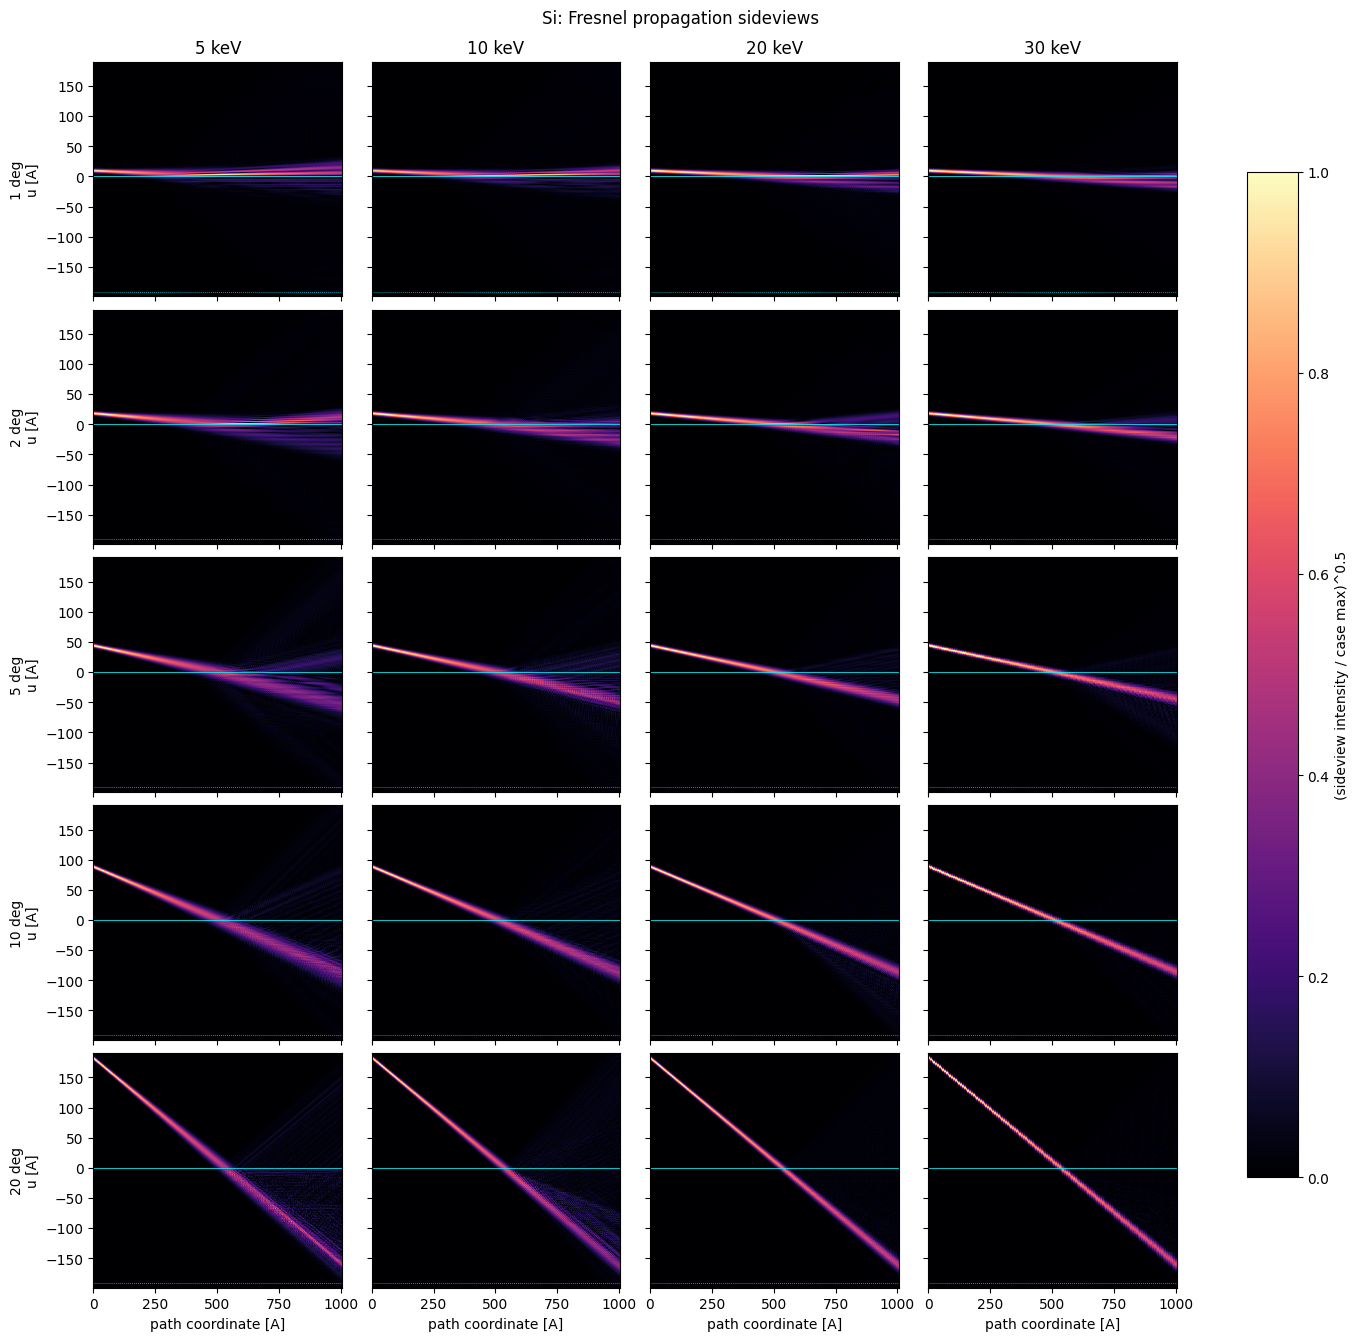

saved Si Angular spectrum sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/si_angular_spectrum_sideviews.png


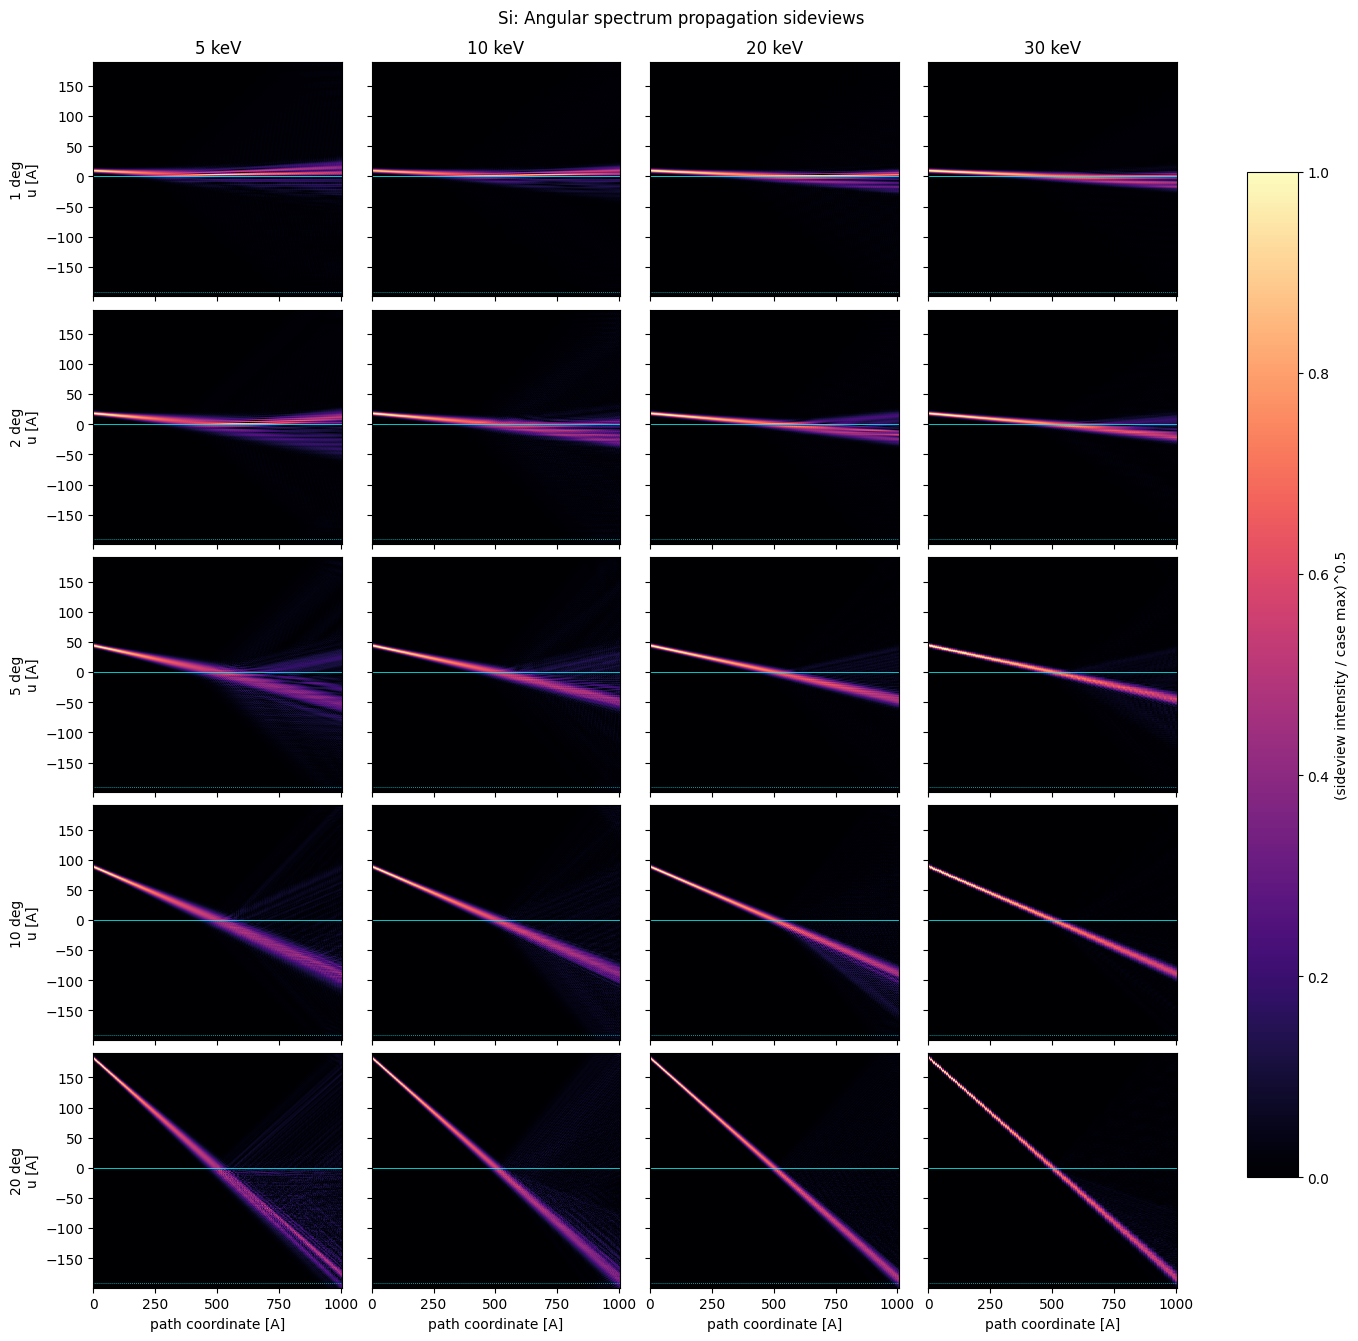

saved Si WPM sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/si_wpm_sideviews.png


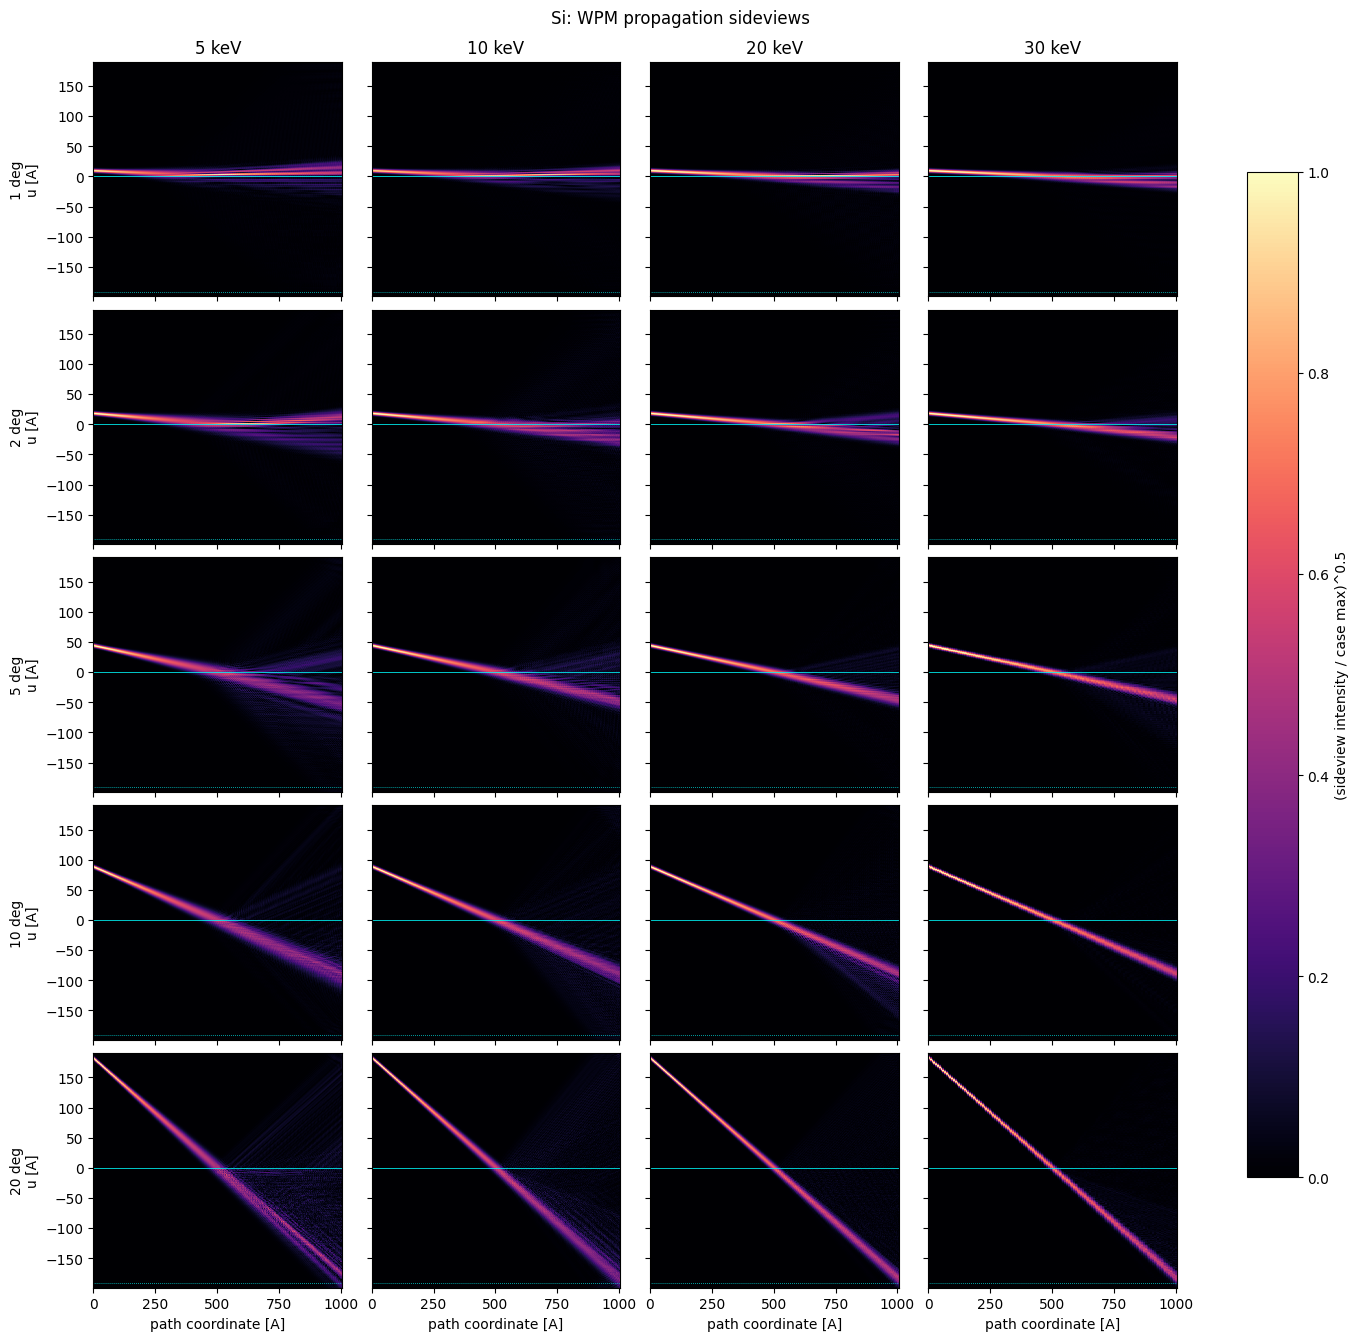

saved Si Pade sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/si_pade_sideviews.png


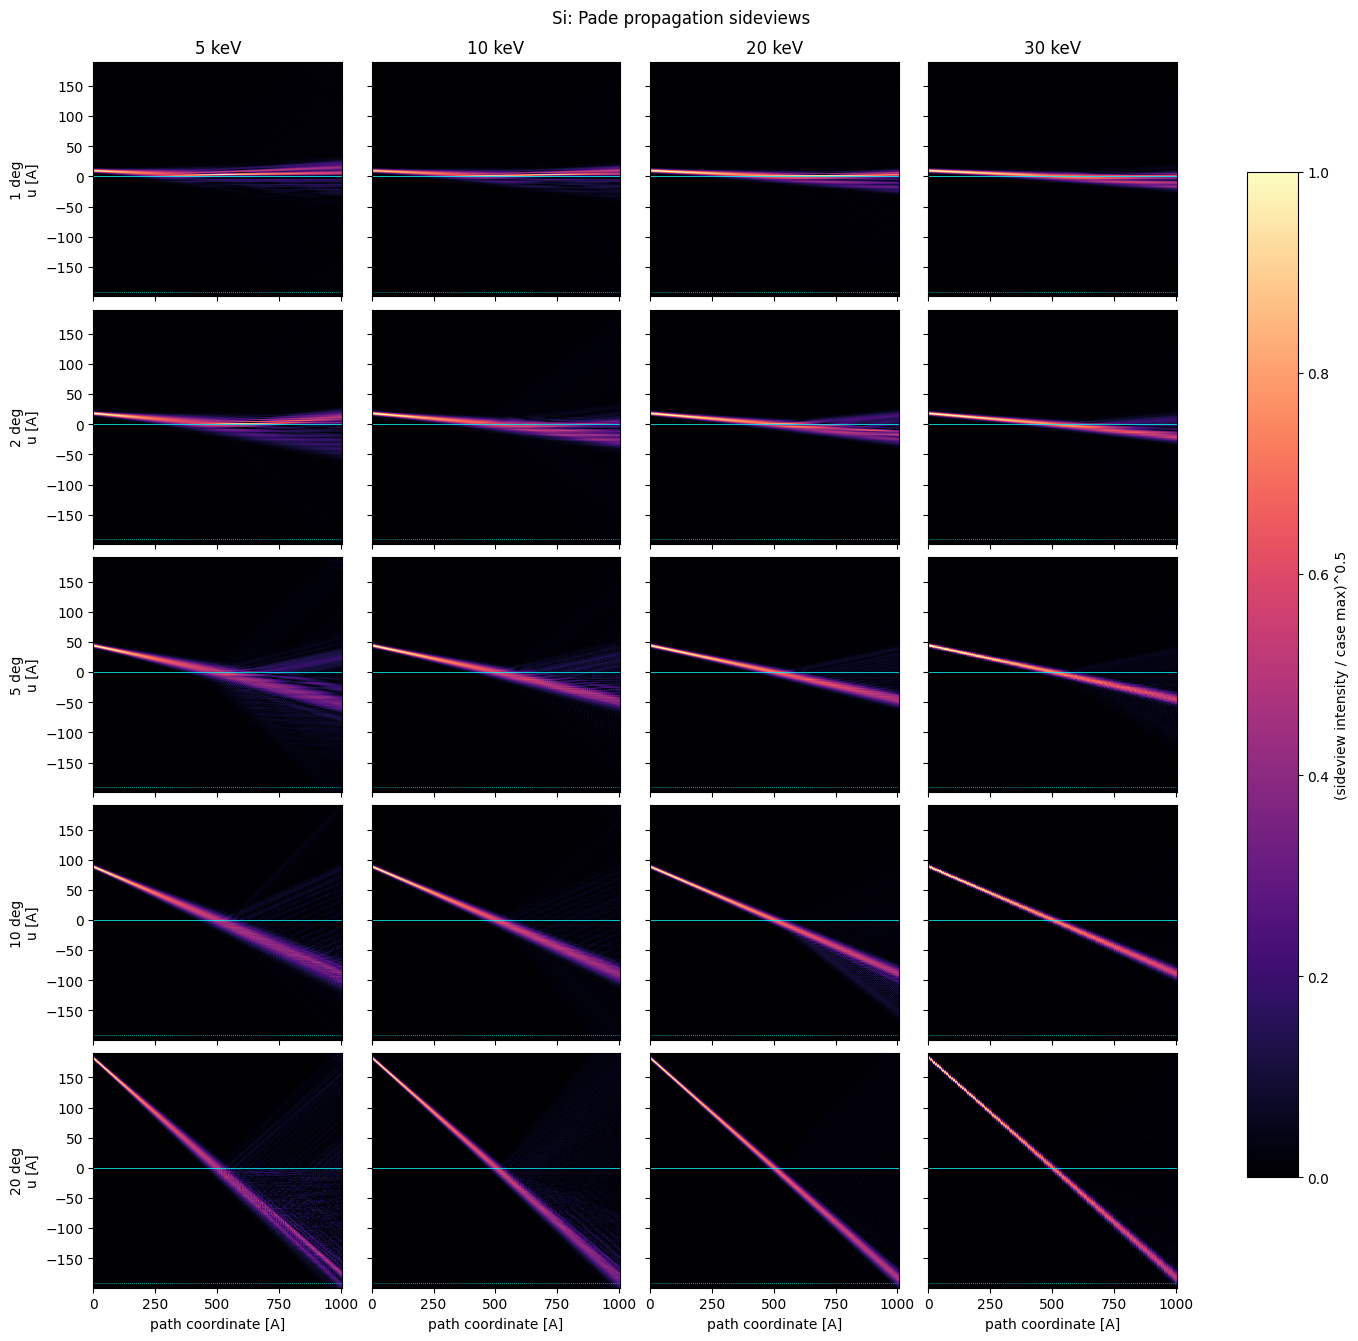

saved Mo Fresnel sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/mo_fresnel_sideviews.png


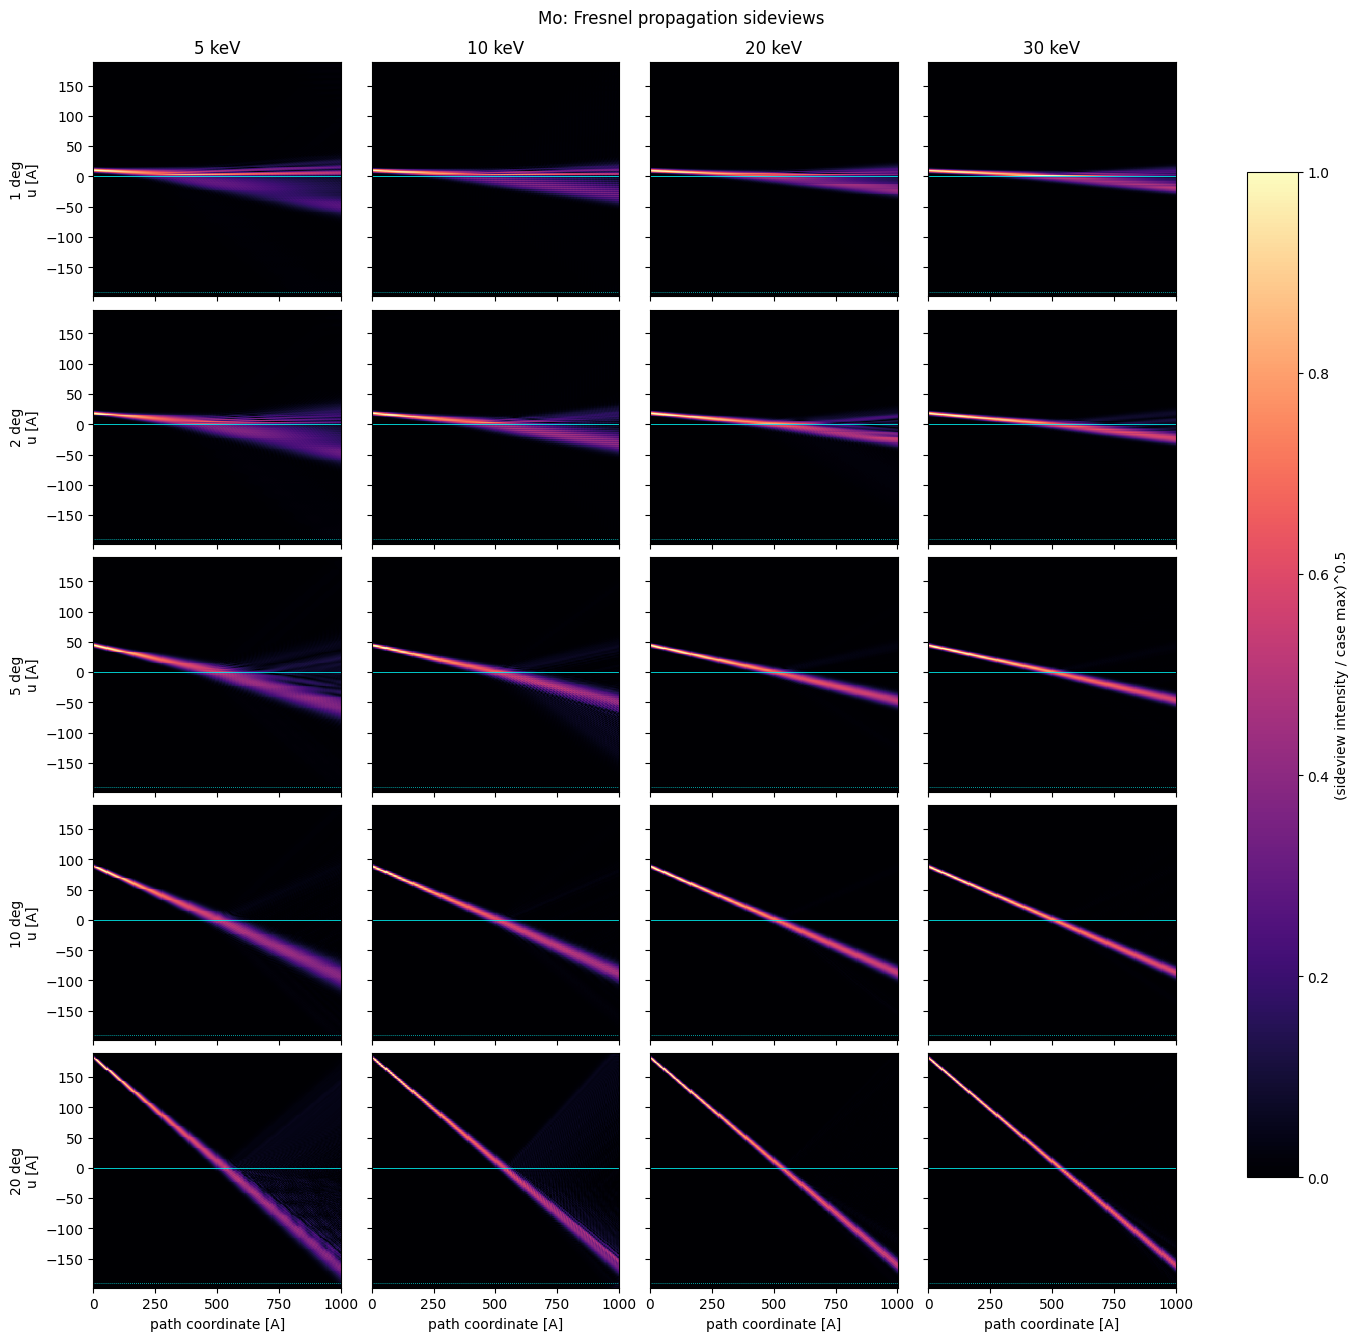

saved Mo Angular spectrum sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/mo_angular_spectrum_sideviews.png


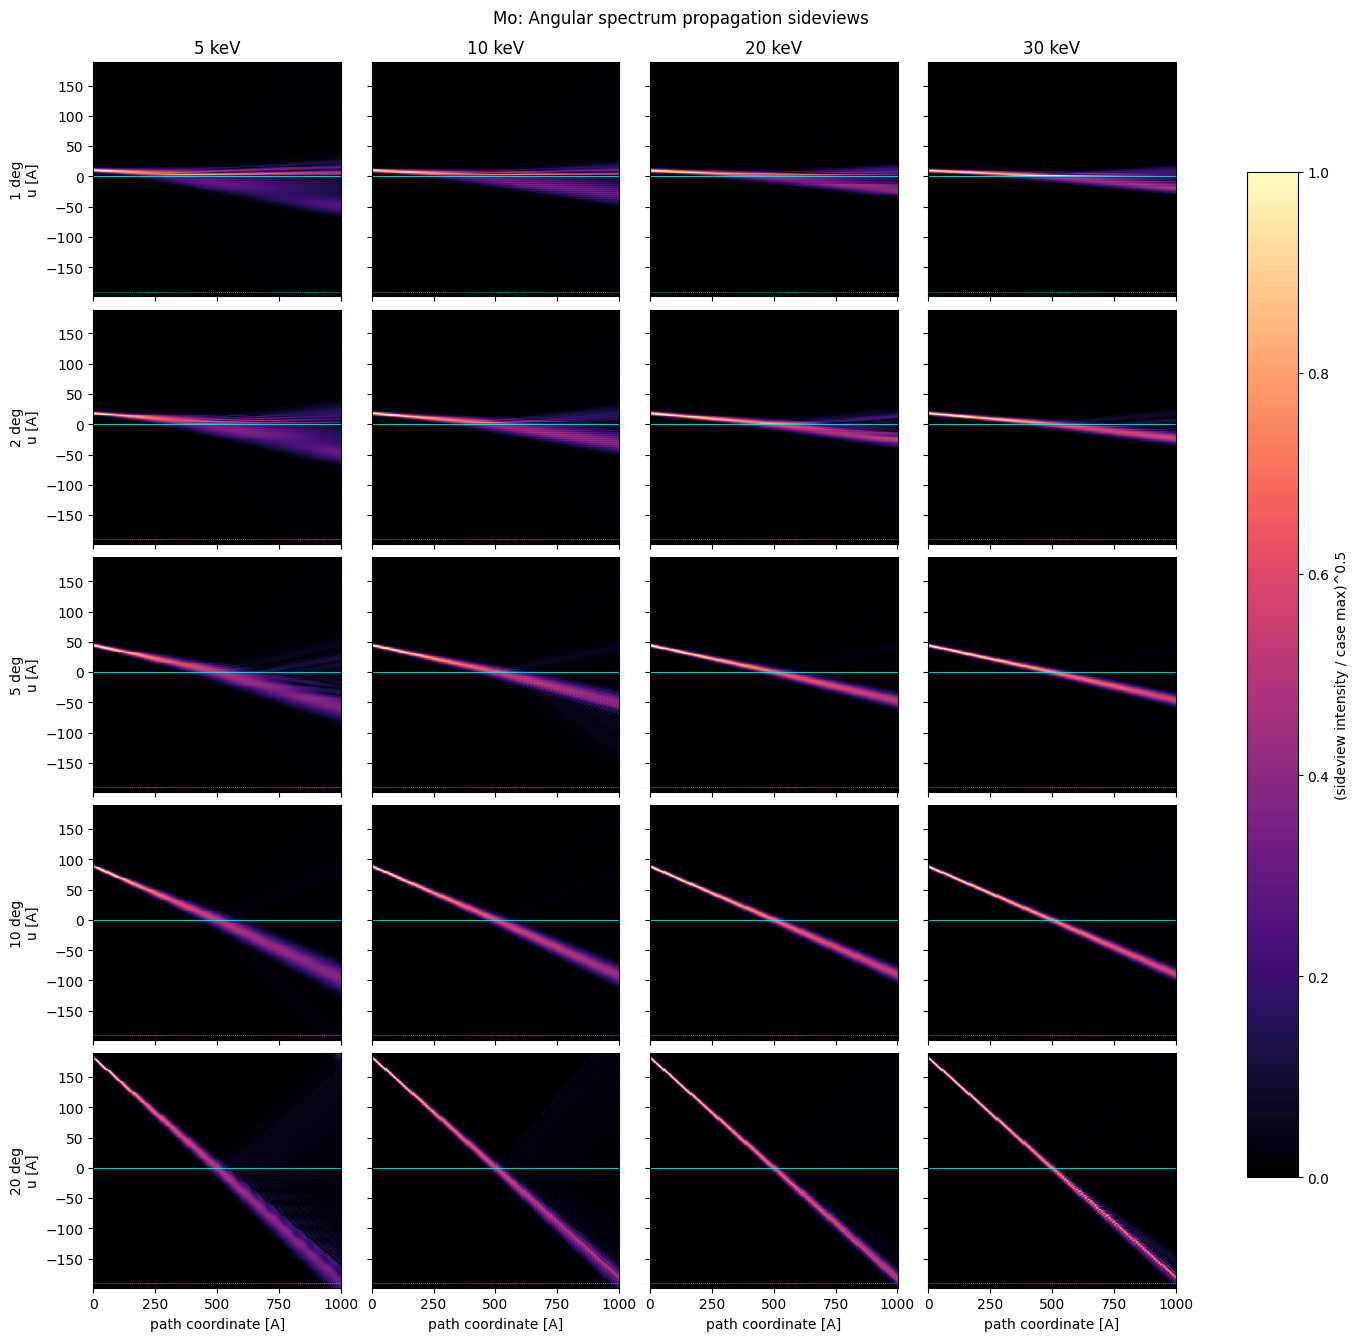

saved Mo WPM sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/mo_wpm_sideviews.png


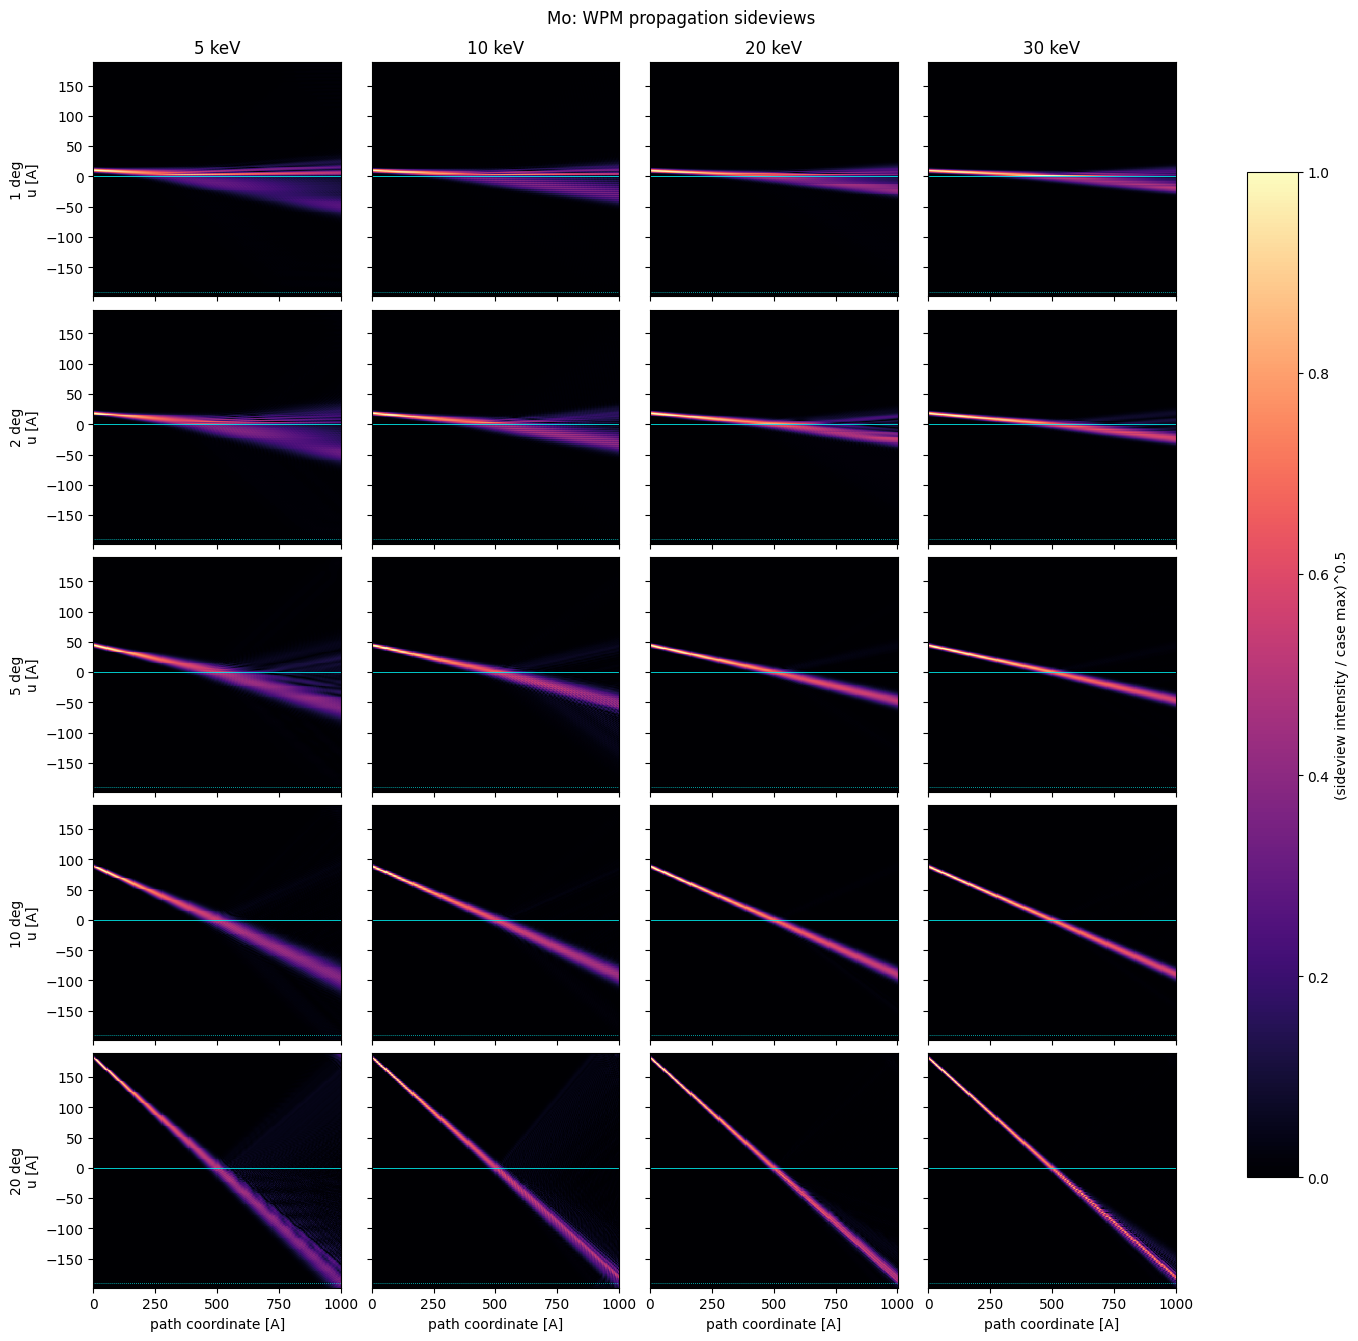

saved Mo Pade sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/mo_pade_sideviews.png


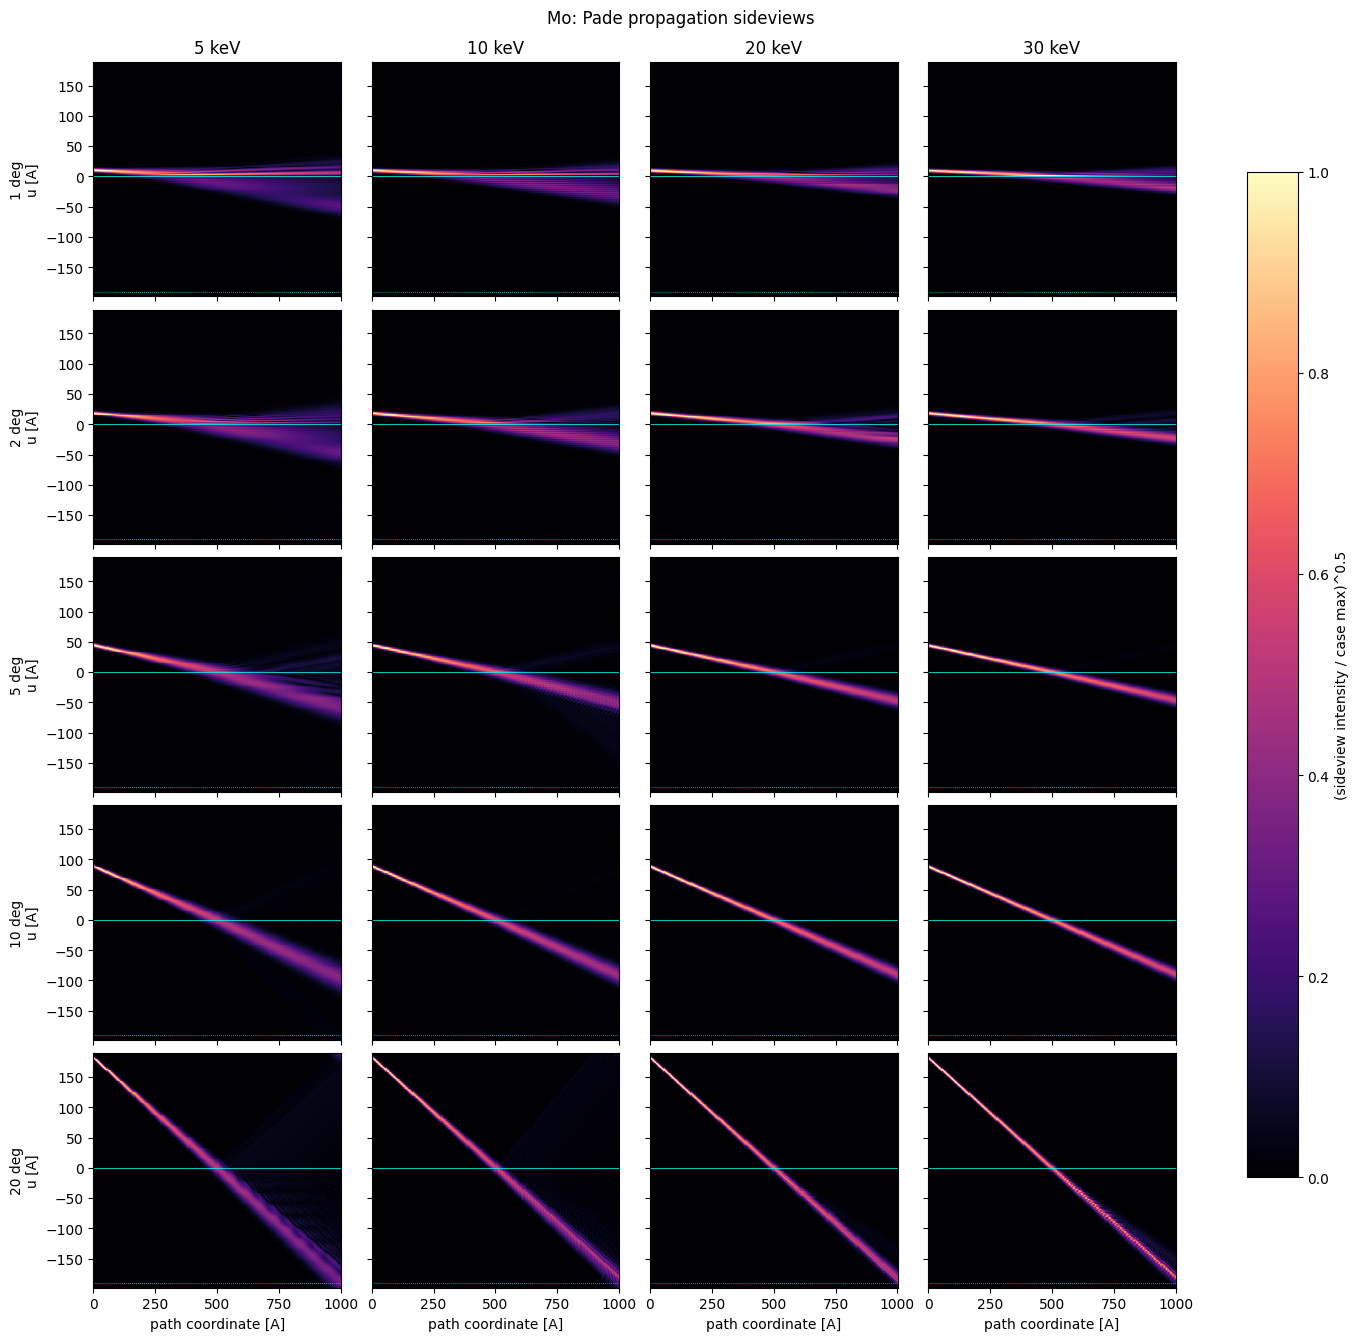

saved Au Fresnel sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/au_fresnel_sideviews.png


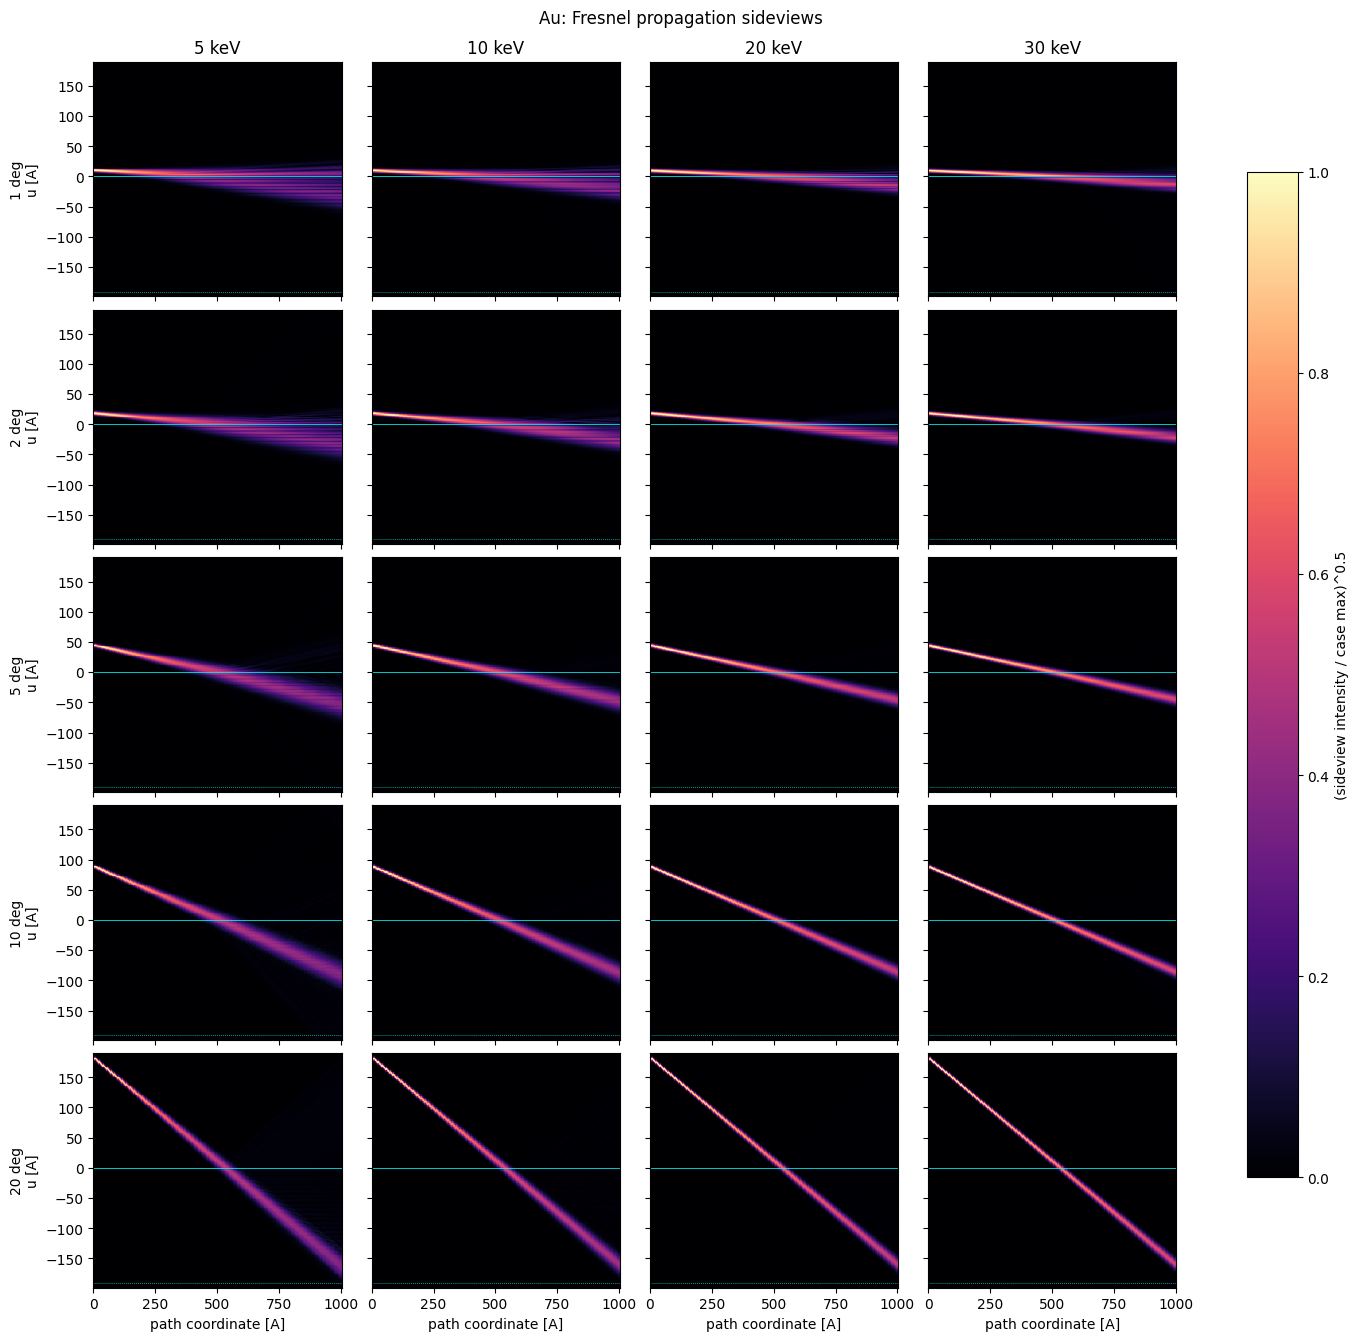

saved Au Angular spectrum sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/au_angular_spectrum_sideviews.png


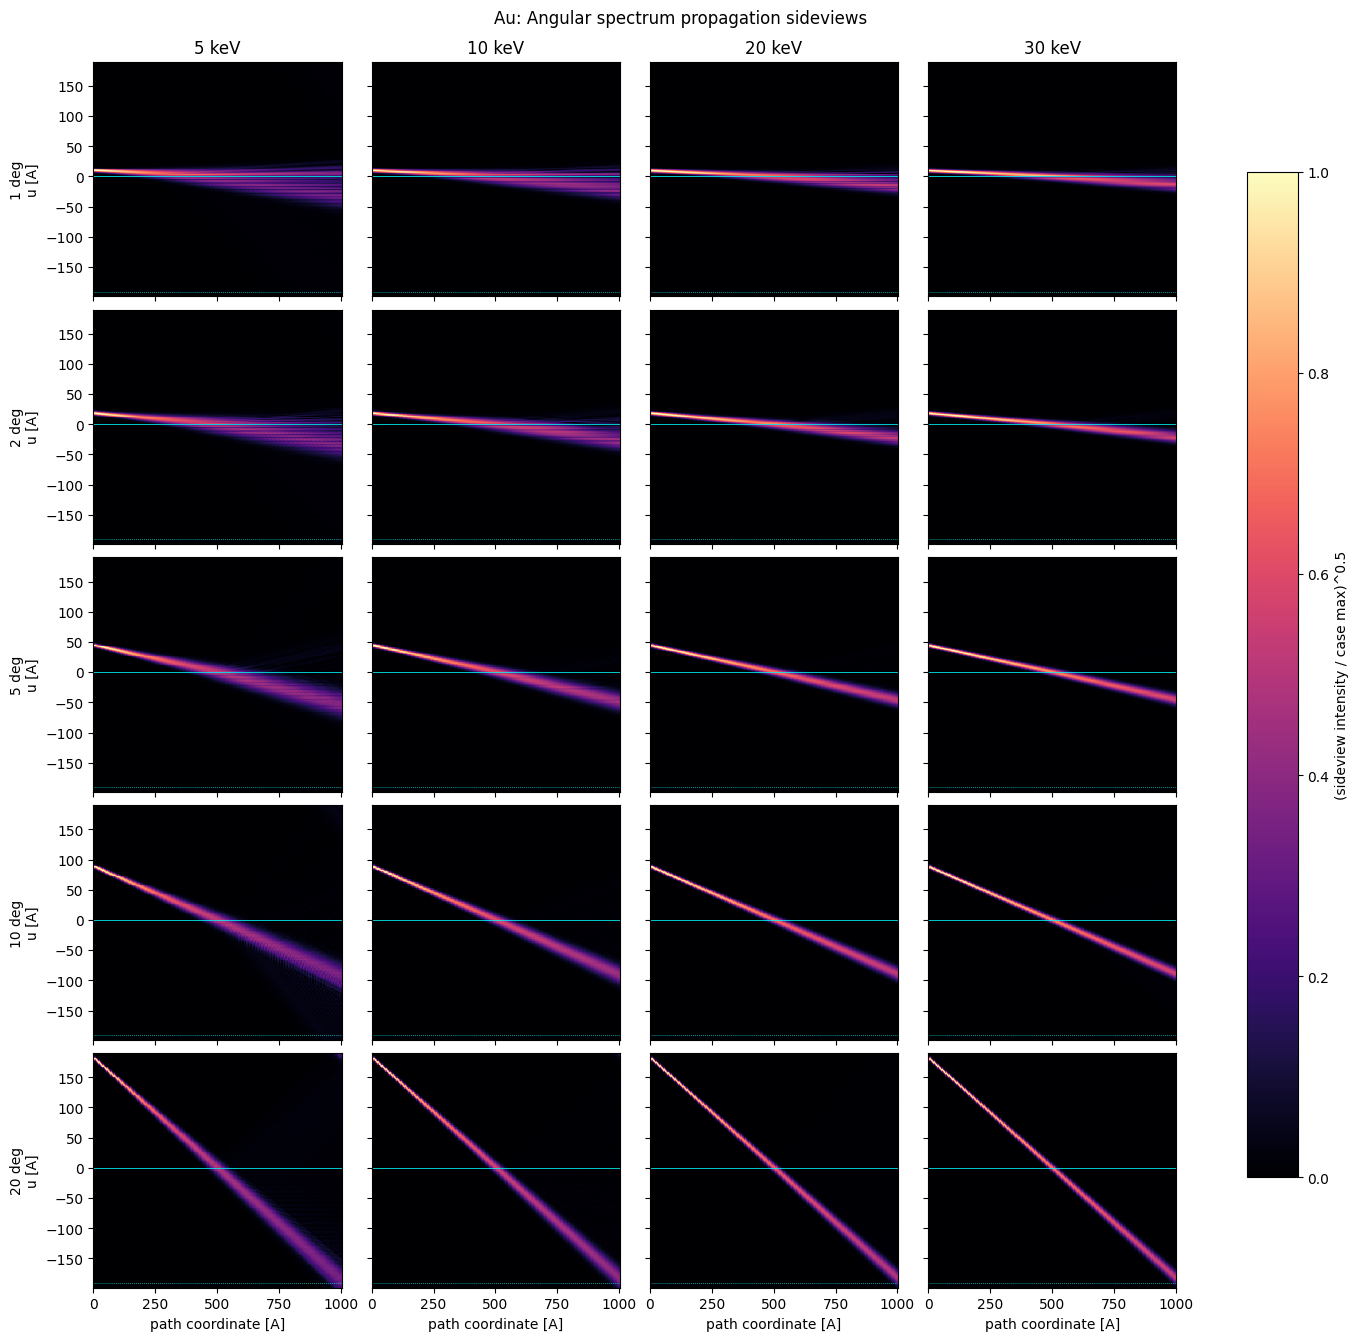

saved Au WPM sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/au_wpm_sideviews.png


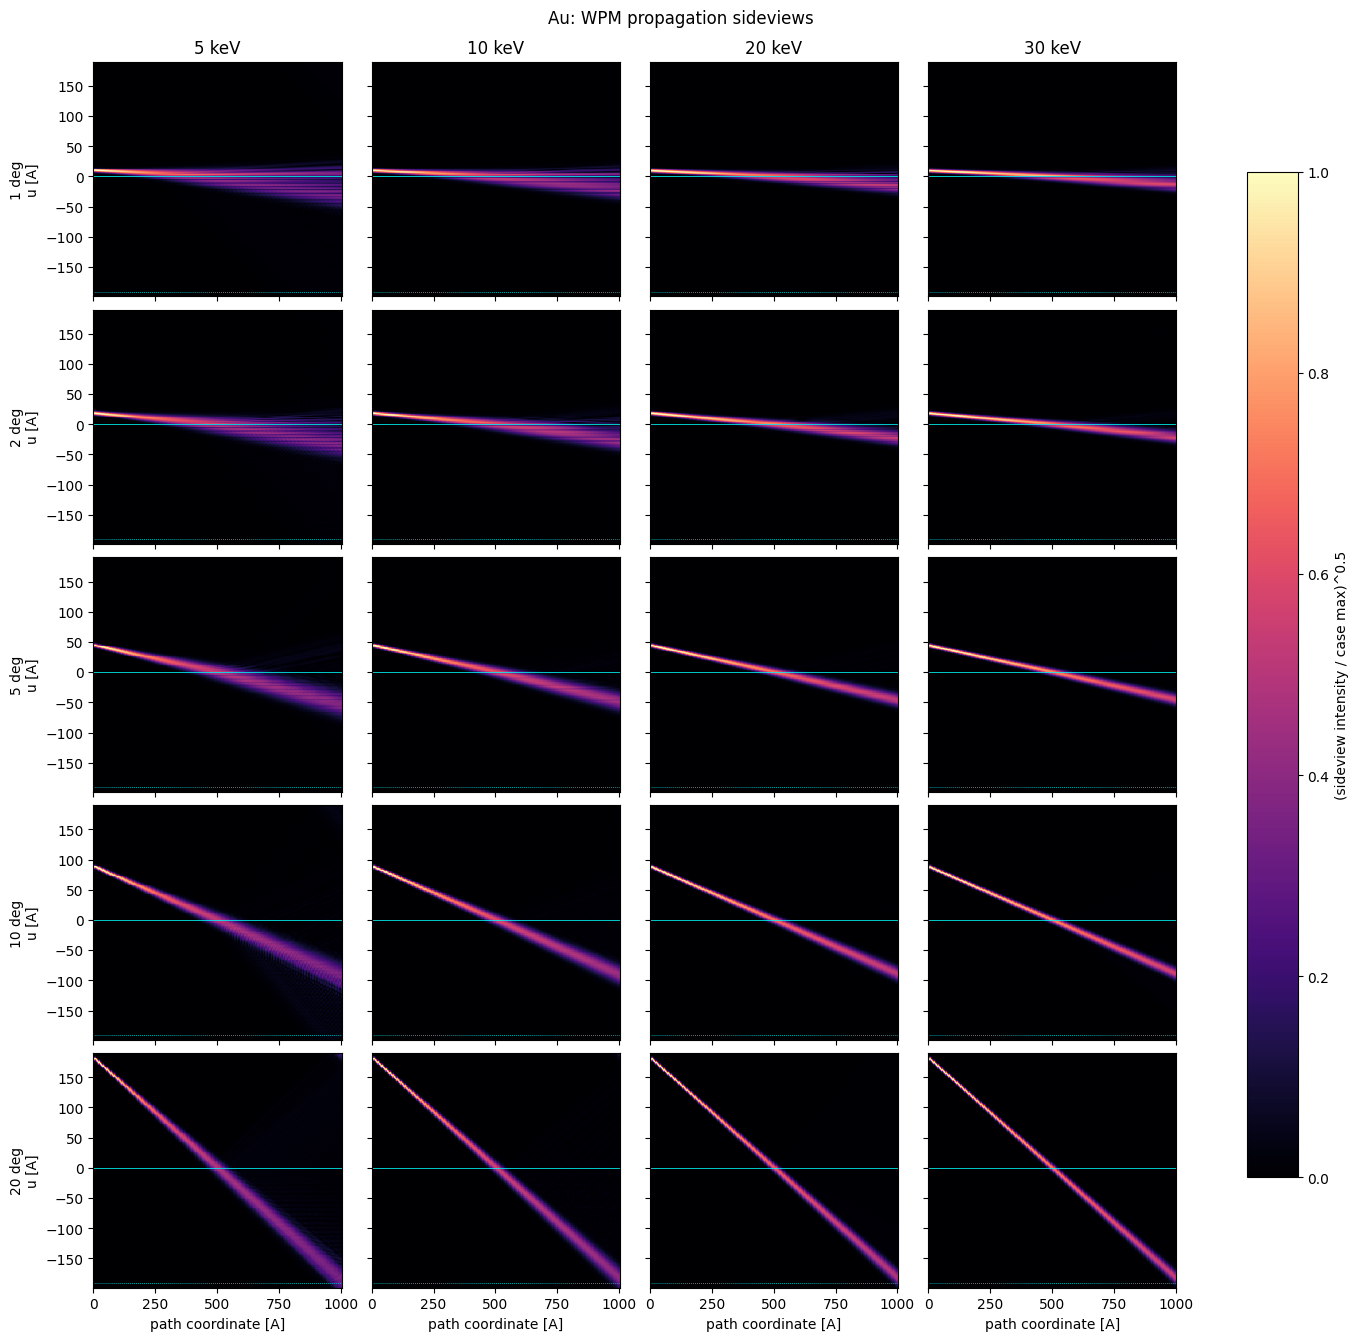

saved Au Pade sideviews to /home/dl277493/Documents/Code/WideAnglePropagation/notebook_results/sideview_glancing_incidence_low_energy_methods/path1000A_spc6_tilt0p75_wpm32_pade44_sweeps1_v6/au_pade_sideviews.png


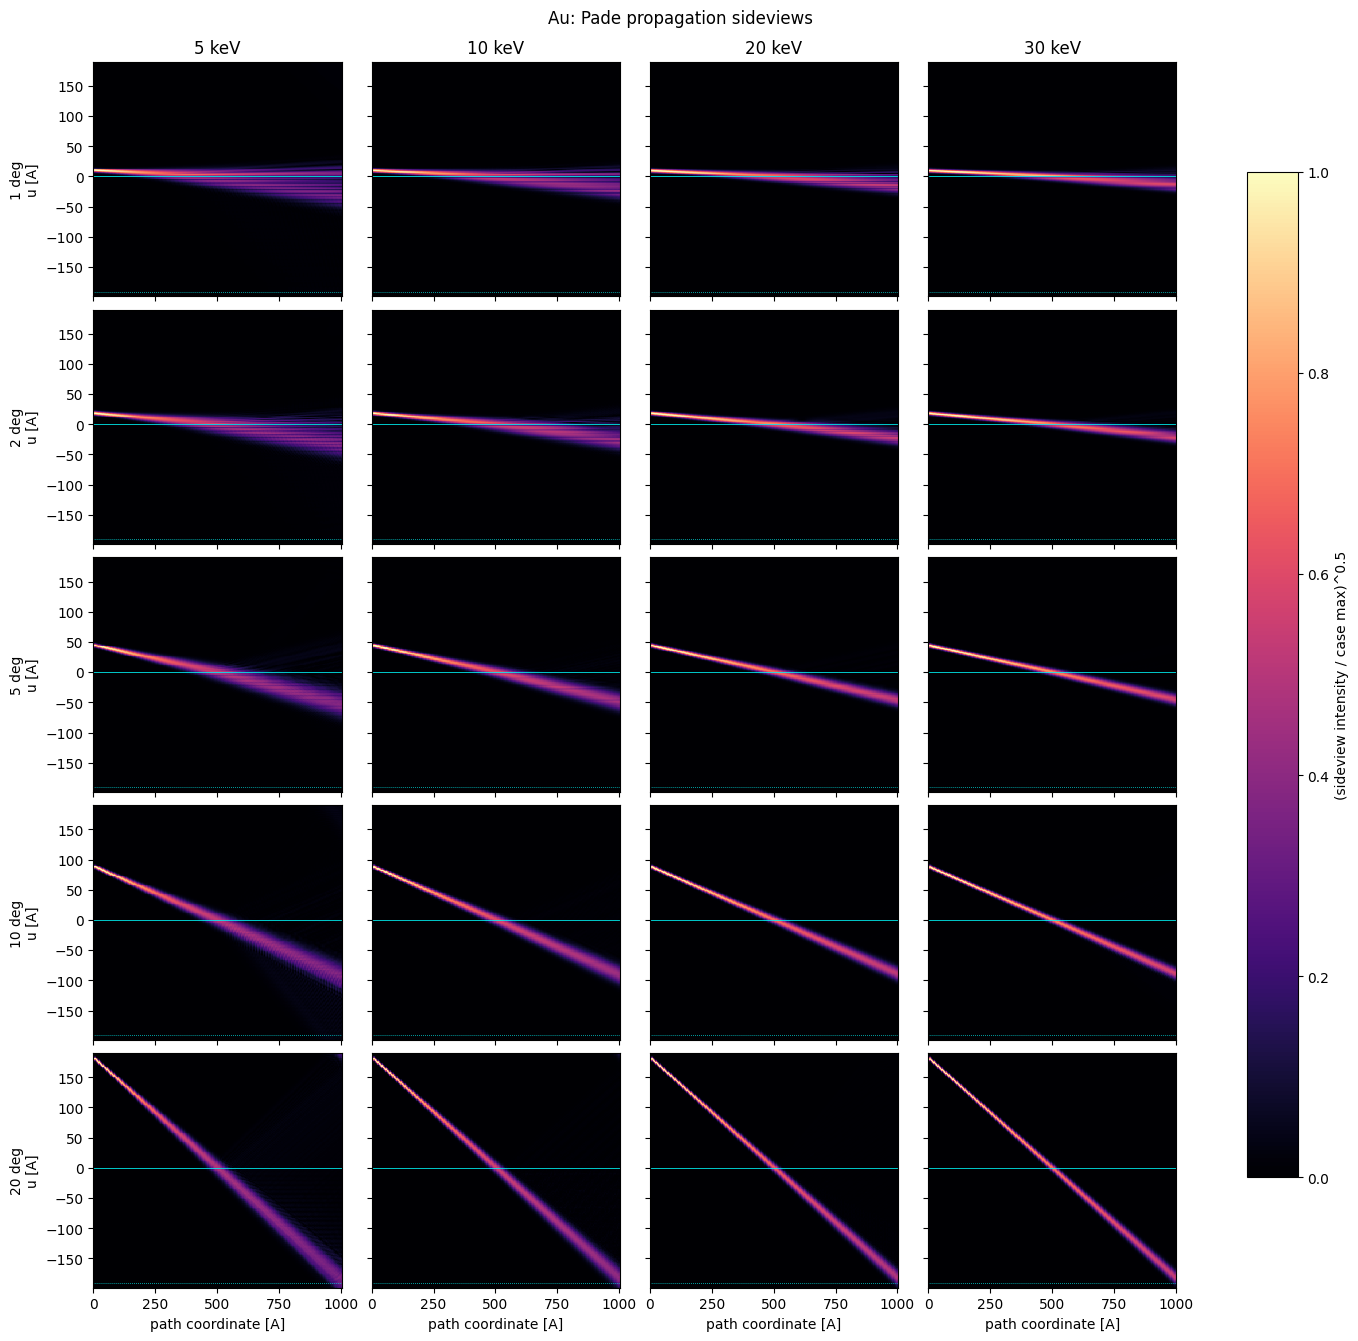

In [12]:
PLOT_SWEEP_SIDEVIEWS = True
SIDEVIEW_DISPLAY_POWER = 0.5
SIDEVIEW_CMAP = "magma"


def load_cached_sideviews(row):
    cache_path = REPO_ROOT / row["cache_file"]
    with np.load(cache_path, allow_pickle=False) as data:
        return {
            "u_A": (
                data["sideview_u_A"].copy()
                if "sideview_u_A" in data.files
                else data["u_A"].copy()
            ),
            "slice_axis_A": (
                data["sideview_slice_axis_A"].copy()
                if "sideview_slice_axis_A" in data.files
                else data["slice_axis_A"].copy()
            ),
            "intensities": {
                method: data[
                    f"{method_key(method)}_sideview_intensity"
                ].copy()
                for method in METHODS
            },
        }


sideview_figure_paths = {}
if sweep_results and PLOT_SWEEP_SIDEVIEWS:
    for material in MATERIAL_SPECS:
        material_cases = {}
        for angle_deg in ANGLES_DEG:
            for energy_keV in ENERGIES_KEV:
                row = next(
                    result
                    for result in sweep_results
                    if result["material"] == material
                    and np.isclose(result["energy_keV"], energy_keV)
                    and np.isclose(result["angle_deg"], angle_deg)
                )
                sideviews = load_cached_sideviews(row)
                sideviews["normalization"] = max(
                    float(np.max(intensity))
                    for intensity in sideviews["intensities"].values()
                ) + 1e-30
                sideviews["row"] = row
                material_cases[(angle_deg, energy_keV)] = sideviews

        for method in METHODS:
            fig, axes = plt.subplots(
                len(ANGLES_DEG),
                len(ENERGIES_KEV),
                figsize=(13.5, 13.0),
                sharex=True,
                sharey=True,
                constrained_layout=True,
            )
            last_image = None
            for angle_index, angle_deg in enumerate(ANGLES_DEG):
                for energy_index, energy_keV in enumerate(ENERGIES_KEV):
                    ax = axes[angle_index, energy_index]
                    sideviews = material_cases[(angle_deg, energy_keV)]
                    row = sideviews["row"]
                    display = (
                        sideviews["intensities"][method]
                        / sideviews["normalization"]
                    ) ** SIDEVIEW_DISPLAY_POWER
                    last_image = ax.imshow(
                        display.T,
                        extent=[
                            0.0,
                            row["path_length_A"],
                            float(sideviews["u_A"][0]),
                            float(sideviews["u_A"][-1]),
                        ],
                        origin="lower",
                        aspect="auto",
                        cmap=SIDEVIEW_CMAP,
                        vmin=0.0,
                        vmax=1.0,
                        interpolation="nearest",
                    )
                    ax.axhline(0.0, color="cyan", lw=0.55)
                    ax.axhline(
                        -row["slab_depth_A"],
                        color="cyan",
                        ls=":",
                        lw=0.55,
                    )
                    if angle_index == 0:
                        ax.set_title(f"{energy_keV:.0f} keV")
                    if energy_index == 0:
                        ax.set_ylabel(f"{angle_deg:.0f} deg\nu [A]")
                    if angle_index == len(ANGLES_DEG) - 1:
                        ax.set_xlabel("path coordinate [A]")

            colorbar = fig.colorbar(last_image, ax=axes, shrink=0.82)
            colorbar.set_label(
                f"(sideview intensity / case max)^{SIDEVIEW_DISPLAY_POWER:g}"
            )
            fig.suptitle(
                f"{material}: {method} propagation sideviews",
                y=1.02,
            )
            figure_path = CASE_CACHE_DIR / (
                f"{material.lower()}_{method_key(method)}_sideviews.png"
            )
            fig.savefig(
                figure_path,
                dpi=180,
                bbox_inches="tight",
                facecolor="white",
            )
            sideview_figure_paths[(material, method)] = figure_path
            print(f"saved {material} {method} sideviews to {figure_path}")
            plt.show()

        del material_cases
        gc.collect()


## Reading the sweep

The detector excludes the transmitted beam and records only positive diffraction angles. The heatmap therefore shows the positive-angle detected-power fraction, evaluated from the unscaled far-field intensity using Parseval normalization by the incident power. Padé remains a selected numerical reference for the method-error diagnostics, but not for the displayed detector signal. The Fresnel and angular-spectrum methods share the same phase-grating split step but use different free-space kernels, whereas WPM also changes how the local refractive index enters propagation. The Padé solution is a useful common reference under the conditions considered here, although finite Padé order, slice thickness, transverse sampling, and the number of backscatter sweeps mean that it should not be interpreted as an exact physical ground truth.

The sideview galleries show the forward-wave intensity throughout each specimen. Every panel is normalized by the largest sideview intensity among all four methods for that material, energy, and angle case, and the square-root display scaling exposes weaker scattered intensity while preserving a common zero-to-one range.

Before extending the path length, first identify the material, energy, and angle regions with the largest stable method separation. Those selected cases can then be rerun with a longer specimen and a convergence sweep over du, path step, WPM bins, Padé order, and backscatter iterations.
